In [1]:
!pip install nltk

In [2]:
!python -m pip install --upgrade pip

In [3]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import nltk

# Download necessary datasets for NLP processing
nltk.download('stopwords')
nltk.download('punkt')

print("Setup complete!")

Setup complete!


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\mapfi\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\mapfi\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [4]:
df = pd.read_csv(
    r"C:\Users\mapfi\OneDrive\Desktop\Electric_Vehicle_Population_Data.csv",
    low_memory=False,
    quotechar='"'
)

df.head()

,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
0,1N4AZ1CPXL,King,Shoreline,WA,98133.0,2020,NISSAN,LEAF,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,149.0,32.0,237906875,POINT (-122.33364 47.73709),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303302e+10
1,ZACPDFDW6R,Kitsap,Bremerton,WA,98311.0,2024,DODGE,HORNET,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,32.0,23.0,267257532,POINT (-122.60915 47.62631),PUGET SOUND ENERGY INC,5.303509e+10
2,5YJYGDEE5L,King,Bellevue,WA,98004.0,2020,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,291.0,48.0,114986196,POINT (-122.1872 47.61001),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303302e+10
3,JTMABACA0R,King,Seattle,WA,98178.0,2024,TOYOTA,BZ4X,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,37.0,267472859,POINT (-122.25031 47.49481),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303301e+10
4,WBY2Z2C54E,King,Bellevue,WA,98004.0,2014,BMW,I8,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,14.0,41.0,205545868,POINT (-122.1872 47.61001),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303302e+10


# Step 1.1 — Data Import

## Code

```python
import pandas as pd

df = pd.read_csv(
    r"C:\Users\mapfi\OneDrive\Desktop\Electric_Vehicle_Population_Data.csv",
    low_memory=False,
    quotechar='"'
)

df.head()
```

## Output

The dataset was imported successfully into a Pandas DataFrame and the first few records were displayed using `df.head()`. The preview confirmed that the file was loaded correctly and that the columns and values were available for further analysis.

## Observations

- The dataset contains information about electric vehicles registered in different locations.
- Key variables include VIN, County, City, State, Postal Code, Model Year, Make, Model, Electric Vehicle Type, CAFV Eligibility, and Electric Range.
- Both categorical and numerical features are present in the dataset.
- The dataset appears suitable for data cleaning, exploratory data analysis (EDA), feature engineering, and machine learning.

## Why This Step Is Important

Importing the dataset is the foundation of every data analysis project. Before any cleaning, visualization, or modeling can be performed, the data must be loaded into a structured format that can be manipulated and analyzed efficiently.

Using `low_memory=False` ensures that Pandas correctly infers data types across the entire dataset, reducing the risk of mixed-type warnings and improving data consistency.

## Next Step

Proceed to inspect the dataset structure by checking:

- Dataset shape (`df.shape`)
- Data types (`df.info()`)
- Missing values (`df.isnull().sum()`)
- Duplicate records (`df.duplicated().sum()`)

These checks will provide an initial understanding of the dataset quality before beginning the data cleaning phase.

In [5]:
# Step 2.1: Dataset Overview
# This step helps me understand the basic structure and quality of the dataset before analysis.

# Display dataset info
df.info()

# Display dataset shape (rows, columns)
print("Dataset Shape:", df.shape)

# Check for missing values
print("\nMissing Values per Column:")
print(df.isnull().sum())

# Display column names
print("\nColumn Names:")
print(df.columns.tolist())

<class 'pandas.DataFrame'>
RangeIndex: 285822 entries, 0 to 285821
Data columns (total 16 columns):
 #   Column                                             Non-Null Count   Dtype  
---  ------                                             --------------   -----  
 0   VIN (1-10)                                         285822 non-null  str    
 1   County                                             285812 non-null  str    
 2   City                                               285812 non-null  str    
 3   State                                              285822 non-null  str    
 4   Postal Code                                        285812 non-null  float64
 5   Model Year                                         285822 non-null  int64  
 6   Make                                               285822 non-null  str    
 7   Model                                              285822 non-null  str    
 8   Electric Vehicle Type                              285822 non-null  str    
 9   Clea

# Step 2.1 — Dataset Structure and Initial Inspection

## Code

```python
# Step 2.1: Dataset Overview
# This step helps me understand the basic structure and quality of the dataset before cleaning.

# Display dataset information
df.info()

# Display dataset shape (rows, columns)
print("Dataset Shape:", df.shape)

# Check for missing values
print("\nMissing Values per Column:")
print(df.isnull().sum())

# Display column names
print("\nColumn Names:")
print(df.columns.tolist())
```

## Output

The dataset contains **285,822 rows** and **16 columns**.

Data types identified:

- String/Object Columns: 10
- Integer Columns: 2
- Float Columns: 4

The dataset occupies approximately **34.9 MB** of memory.

Several columns contain missing values, including:

- County (10)
- City (10)
- Postal Code (10)
- Electric Range (8)
- Legislative District (733)
- Vehicle Location (18)
- Electric Utility (10)
- 2020 Census Tract (10)

Most columns are highly complete, with missing values representing a very small percentage of the overall dataset.

## Observations

- The dataset is large enough for meaningful analysis and machine learning.
- The majority of columns contain complete records.
- The most significant missing-value issue appears in **Legislative District**, although it still represents a very small proportion of the dataset.
- Both categorical and numerical features are present.
- Electric vehicle information includes geographic, vehicle specification, and eligibility-related attributes.
- The dataset appears suitable for regression, classification, clustering, and visualization tasks.

## Why This Step Is Important

Inspecting the dataset structure provides an understanding of:

- Dataset size and complexity.
- Available features for analysis.
- Data types that may require conversion.
- Missing-value patterns that must be handled during data cleaning.
- Potential target variables for future machine learning tasks.

This step serves as the foundation for all subsequent data preparation and analysis activities.

## Next Step

Proceed to perform a detailed dataset inspection by:

1. Displaying the first and last records.
2. Reviewing summary statistics for numerical variables.
3. Examining unique values in categorical columns.
4. Checking for duplicate records.
5. Identifying potential columns that may require cleaning, transformation, or feature engineering.

This deeper inspection will help determine the most appropriate data-cleaning strategy before moving into Exploratory Data Analysis (EDA).

In [6]:
# Step 3: Check for missing values
missing_values = df.isnull().sum().sort_values(ascending=False)

# Display top missing columns
print("Missing Values per Column:\n")
print(missing_values)

# Optional: show percentage of missing values for better context
missing_percent = (df.isnull().sum() / len(df)) * 100
print("\nPercentage of Missing Values:\n")
print(missing_percent.sort_values(ascending=False))


Missing Values per Column:

Legislative District                                 733
Vehicle Location                                      18
County                                                10
City                                                  10
2020 Census Tract                                     10
Electric Utility                                      10
Postal Code                                           10
Electric Range                                         8
Model                                                  0
Make                                                   0
Model Year                                             0
State                                                  0
VIN (1-10)                                             0
Clean Alternative Fuel Vehicle (CAFV) Eligibility      0
Electric Vehicle Type                                  0
DOL Vehicle ID                                         0
dtype: int64

Percentage of Missing Values:

Legislative Dis

# Step 2.1 — Dataset Structure and Initial Inspection

## Code

```python
# Step 2.1: Dataset Overview
# This step helps me understand the basic structure and quality of the dataset before cleaning.

# Display dataset information
df.info()

# Display dataset shape (rows, columns)
print("Dataset Shape:", df.shape)

# Check for missing values
print("\nMissing Values per Column:")
print(df.isnull().sum())

# Display column names
print("\nColumn Names:")
print(df.columns.tolist())
```

## Output

The dataset contains **285,822 rows** and **16 columns**.

Data types identified:

- String/Object Columns: 10
- Integer Columns: 2
- Float Columns: 4

The dataset occupies approximately **34.9 MB** of memory.

Several columns contain missing values, including:

- County (10)
- City (10)
- Postal Code (10)
- Electric Range (8)
- Legislative District (733)
- Vehicle Location (18)
- Electric Utility (10)
- 2020 Census Tract (10)

Most columns are highly complete, with missing values representing a very small percentage of the overall dataset.

## Observations

- The dataset is large enough for meaningful analysis and machine learning.
- The majority of columns contain complete records.
- The most significant missing-value issue appears in **Legislative District**, although it still represents a very small proportion of the dataset.
- Both categorical and numerical features are present.
- Electric vehicle information includes geographic, vehicle specification, and eligibility-related attributes.
- The dataset appears suitable for regression, classification, clustering, and visualization tasks.

## Why This Step Is Important

Inspecting the dataset structure provides an understanding of:

- Dataset size and complexity.
- Available features for analysis.
- Data types that may require conversion.
- Missing-value patterns that must be handled during data cleaning.
- Potential target variables for future machine learning tasks.

This step serves as the foundation for all subsequent data preparation and analysis activities.

## Next Step

Proceed to perform a detailed dataset inspection by:

1. Displaying the first and last records.
2. Reviewing summary statistics for numerical variables.
3. Examining unique values in categorical columns.
4. Checking for duplicate records.
5. Identifying potential columns that may require cleaning, transformation, or feature engineering.

This deeper inspection will help determine the most appropriate data-cleaning strategy before moving into Exploratory Data Analysis (EDA).

In [7]:
# Remove rows with missing values

df_clean = df.dropna()

print("Original Shape:", df.shape)
print("Cleaned Shape:", df_clean.shape)

# Verify no missing values remain
print(df_clean.isnull().sum().sum())

Original Shape: (285822, 16)
Cleaned Shape: (285073, 16)
0


# Step 3.1 — Handling Missing Values

## Objective
In this step, I addressed the missing values identified during the dataset inspection phase. Since the proportion of missing data was extremely small (less than 0.3% of the dataset), I chose to remove the affected records rather than perform imputation.

## Code Used

```python
# Remove rows with missing values

df_clean = df.dropna()

print("Original Shape:", df.shape)
print("Cleaned Shape:", df_clean.shape)

# Verify no missing values remain
print(df_clean.isnull().sum().sum())
```

## Output

```text
Original Shape: (285822, 16)
Cleaned Shape: (285073, 16)
0
```

## Observations

- The original dataset contained **285,822 rows** and **16 columns**.
- After removing records containing missing values, the dataset contained **285,073 rows**.
- A total of **749 records** were removed.
- Verification confirmed that **no missing values remain** in the cleaned dataset.
- The number of removed records represents a very small percentage of the dataset and is unlikely to affect the overall analysis.

## Importance

Handling missing values is an essential data-cleaning step because machine learning algorithms and statistical analyses often require complete data. Removing a very small number of incomplete records helps maintain data quality without introducing potential bias from imputation methods.

## Next Step

Proceed to check for duplicate records in the cleaned dataset to ensure data integrity before continuing with further cleaning, exploratory data analysis (EDA), and feature engineering.

In [8]:
df_clean

,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
0,1N4AZ1CPXL,King,Shoreline,WA,98133.0,2020,NISSAN,LEAF,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,149.0,32.0,237906875,POINT (-122.33364 47.73709),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303302e+10
1,ZACPDFDW6R,Kitsap,Bremerton,WA,98311.0,2024,DODGE,HORNET,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,32.0,23.0,267257532,POINT (-122.60915 47.62631),PUGET SOUND ENERGY INC,5.303509e+10
2,5YJYGDEE5L,King,Bellevue,WA,98004.0,2020,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,291.0,48.0,114986196,POINT (-122.1872 47.61001),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303302e+10
3,JTMABACA0R,King,Seattle,WA,98178.0,2024,TOYOTA,BZ4X,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,37.0,267472859,POINT (-122.25031 47.49481),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303301e+10
4,WBY2Z2C54E,King,Bellevue,WA,98004.0,2014,BMW,I8,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,14.0,41.0,205545868,POINT (-122.1872 47.61001),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303302e+10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
285817,7FCTGBAA7S,King,Kirkland,WA,98033.0,2025,RIVIAN,R1T,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,45.0,274271973,POINT (-122.2066 47.67887),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303302e+10
285818,7SAXCAE5XR,Kitsap,Silverdale,WA,98383.0,2024,TESLA,MODEL X,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,23.0,267483982,POINT (-122.69275 47.65171),PUGET SOUND ENERGY INC,5.303509e+10
285819,1C4RJYD67P,King,Covington,WA,98042.0,2023,JEEP,GRAND CHEROKEE,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,25.0,47.0,240649622,POINT (-122.10798 47.37124),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303303e+10
285820,7PDSGABL0P,Snohomish,Edmonds,WA,98026.0,2023,RIVIAN,R1S,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,21.0,233617534,POINT (-122.31768 47.87166),PUGET SOUND ENERGY INC,5.306105e+10


In [9]:
# Step 5: Detect and handle duplicates

# Check for duplicate records
duplicate_count = df_clean.duplicated().sum()
print(f"Number of duplicate rows before removal: {duplicate_count}")

# Display a few duplicate rows (if any)
if duplicate_count > 0:
    display(df[df_clean.duplicated()].head())

# Remove duplicate rows
df = df_clean.drop_duplicates()

# Verify duplicates are removed
print(f"Number of duplicate rows after removal: {df.duplicated().sum()}")
print(f"Total remaining rows in dataset: {len(df)}")

Number of duplicate rows before removal: 0
Number of duplicate rows after removal: 0
Total remaining rows in dataset: 285073


# Step 5 — Duplicate Record Detection and Removal

## Objective

In this step, I checked the cleaned dataset for duplicate records and removed them if any were found. Duplicate records can lead to biased analysis, inaccurate statistics, and misleading machine learning results, so it is important to verify data uniqueness before proceeding.

## Code Used

```python
# Check for duplicate records
duplicate_count = df_clean.duplicated().sum()

print(f"Number of duplicate rows before removal: {duplicate_count}")

# Display a few duplicate rows (if any)
if duplicate_count > 0:
    display(df_clean[df_clean.duplicated()].head())

# Remove duplicate rows
df = df_clean.drop_duplicates()

# Verify duplicates are removed
print(f"Number of duplicate rows after removal: {df.duplicated().sum()}")
print(f"Total remaining rows in dataset: {len(df)}")
```

## Output

```text
Number of duplicate rows before removal: 0
Number of duplicate rows after removal: 0
Total remaining rows in dataset: 285073
```

## Observations

- The cleaned dataset contained **0 duplicate records**.
- No rows were removed during the duplicate-check process.
- The dataset size remained **285,073 rows and 16 columns**.
- This confirms that each record in the dataset is unique and no duplicate observations exist.

## Importance

Duplicate records can distort summary statistics, influence machine learning models, and introduce bias into analytical results. Confirming that no duplicates exist improves data quality and ensures that future analysis is based on unique observations only.

## Next Step

Identify categorical and numerical columns


In [10]:
# Step 6.1: Identify categorical and numerical columns

# Display all column names
print("All Columns:\n", df_clean.columns.tolist(), "\n")

# Identify numerical columns (int or float types)
num_cols = df_clean.select_dtypes(include=['int64', 'float64']).columns.tolist()
print("Numerical Columns:\n", num_cols, "\n")

# Identify categorical columns (object or string types)
cat_cols = df_clean.select_dtypes(include=['object']).columns.tolist()
print("Categorical Columns:\n", cat_cols, "\n")

# Count of each type
print(f"Total Numerical Columns: {len(num_cols)}")
print(f"Total Categorical Columns: {len(cat_cols)}")


All Columns:
 ['VIN (1-10)', 'County', 'City', 'State', 'Postal Code', 'Model Year', 'Make', 'Model', 'Electric Vehicle Type', 'Clean Alternative Fuel Vehicle (CAFV) Eligibility', 'Electric Range', 'Legislative District', 'DOL Vehicle ID', 'Vehicle Location', 'Electric Utility', '2020 Census Tract'] 

Numerical Columns:
 ['Postal Code', 'Model Year', 'Electric Range', 'Legislative District', 'DOL Vehicle ID', '2020 Census Tract'] 

Categorical Columns:
 ['VIN (1-10)', 'County', 'City', 'State', 'Make', 'Model', 'Electric Vehicle Type', 'Clean Alternative Fuel Vehicle (CAFV) Eligibility', 'Vehicle Location', 'Electric Utility'] 

Total Numerical Columns: 6
Total Categorical Columns: 10


C:\Users\mapfi\AppData\Local\Temp\ipykernel_12656\4156336718.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df_clean.select_dtypes(include=['object']).columns.tolist()


# Step 6.1 — Identify Numerical and Categorical Features

## Objective

In this step, I examined the dataset structure to identify numerical and categorical variables. Understanding the data types of each feature is important because different preprocessing and analysis techniques are applied to numerical and categorical data.

## Code Used

```python
# Display all column names
print("All Columns:\n", df_clean.columns.tolist(), "\n")

# Identify numerical columns
num_cols = df_clean.select_dtypes(include=['int64', 'float64']).columns.tolist()
print("Numerical Columns:\n", num_cols, "\n")

# Identify categorical columns
cat_cols = df_clean.select_dtypes(include=['object']).columns.tolist()
print("Categorical Columns:\n", cat_cols, "\n")

# Count each type
print(f"Total Numerical Columns: {len(num_cols)}")
print(f"Total Categorical Columns: {len(cat_cols)}")
```

## Output Summary

```text
Total Numerical Columns: 6
Total Categorical Columns: 10
```

### Numerical Features

- Postal Code
- Model Year
- Electric Range
- Legislative District
- DOL Vehicle ID
- 2020 Census Tract

### Categorical Features

- VIN (1-10)
- County
- City
- State
- Make
- Model
- Electric Vehicle Type
- Clean Alternative Fuel Vehicle (CAFV) Eligibility
- Vehicle Location
- Electric Utility

## Observations

- The dataset contains a total of **16 features**.
- **6 columns** are numerical and can be used for statistical analysis and visualizations such as histograms, boxplots, and correlation analysis.
- **10 columns** are categorical and will require categorical analysis techniques such as frequency counts, bar charts, and encoding for machine learning.
- The dataset contains a balanced mix of numerical and categorical information, which is useful for both exploratory analysis and predictive modeling.

## Importance

Identifying feature types is a critical preprocessing step because:

- Numerical variables require scaling, normalization, and statistical analysis.
- Categorical variables require encoding before machine learning.
- Different visualization techniques are used depending on the variable type.
- Proper feature classification helps guide the entire data-cleaning and EDA workflow.

## Next Step
Inspect Current Data Types



In [11]:
# Step 7 — Inspect Current Data Types
df_clean.dtypes.value_counts()

str        10
float64     4
int64       2
Name: count, dtype: int64

# Step 7 — Inspect Current Data Types

## Objective

In this step, I reviewed the current data type distribution of all columns in the cleaned dataset. Understanding the data types helps confirm that each feature has been imported correctly and determines whether any type conversions will be required before analysis or machine learning.

## Code Used

```python
# Step 7 — Inspect Current Data Types
df_clean.dtypes.value_counts()
```

## Output

```text
str        10
float64     4
int64       2
```

## Observations

- The dataset contains a total of **16 columns**.
- **10 columns** are stored as string (`str`) data types.
- **4 columns** are stored as floating-point (`float64`) data types.
- **2 columns** are stored as integer (`int64`) data types.
- The data type distribution matches the earlier feature classification, confirming consistency within the dataset.

## Importance

Inspecting data types is important because:

- Numerical variables must have numeric data types for statistical analysis and machine learning.
- Categorical variables should be stored as string or category types.
- Incorrect data types can cause errors during calculations, visualizations, and model training.
- Early validation helps identify columns that may require conversion before feature engineering.

## Conclusion

The dataset currently contains:

- **10 Categorical Features (String)**
- **4 Continuous Numerical Features (Float)**
- **2 Discrete Numerical Features (Integer)**

The overall data structure appears consistent and suitable for further exploration.

## Next Step

Proceed to inspect each column individually using:

```python
df_clean.dtypes
```

This will allow me to verify that every column has the correct data type and identify any columns that may require type conversion before Exploratory Data Analysis (EDA).
```

In [12]:
df_clean.dtypes

VIN (1-10)                                               str
County                                                   str
City                                                     str
State                                                    str
Postal Code                                          float64
Model Year                                             int64
Make                                                     str
Model                                                    str
Electric Vehicle Type                                    str
Clean Alternative Fuel Vehicle (CAFV) Eligibility        str
Electric Range                                       float64
Legislative District                                 float64
DOL Vehicle ID                                         int64
Vehicle Location                                         str
Electric Utility                                         str
2020 Census Tract                                    float64
dtype: object

# Step 7.1 — Detailed Column Data Type Inspection

## Objective

In this step, I inspected the data type of every individual column in the cleaned dataset. This helps verify that each feature has been assigned an appropriate data type and identifies any columns that may require conversion before Exploratory Data Analysis (EDA) or machine learning.

## Code Used

```python
df_clean.dtypes
```

## Output Summary

### Categorical Columns (String)

```text
VIN (1-10)
County
City
State
Make
Model
Electric Vehicle Type
Clean Alternative Fuel Vehicle (CAFV) Eligibility
Vehicle Location
Electric Utility
```

### Numerical Columns (Integer)

```text
Model Year
DOL Vehicle ID
```

### Numerical Columns (Float)

```text
Postal Code
Electric Range
Legislative District
2020 Census Tract
```

## Observations

- The dataset contains **10 categorical columns** stored as string (`str`) data types.
- The dataset contains **2 integer columns** (`int64`).
- The dataset contains **4 floating-point columns** (`float64`).
- Most columns appear to have appropriate data types for their contents.
- Some numerical identifier fields such as **Postal Code**, **Legislative District**, and **2020 Census Tract** are stored as numeric values but may function more as identifiers than true numerical variables.
- The dataset structure remains consistent after the cleaning process.

## Importance

Inspecting individual column data types is important because:

- It confirms successful data import and cleaning.
- It helps identify columns that may require type conversion.
- It prevents errors during statistical analysis and machine learning.
- It allows proper separation of categorical and numerical features for preprocessing and visualization.

## Conclusion

The dataset currently contains a clean and consistent mix of categorical and numerical features. No immediate data type issues are visible, although identifier-type numerical columns may require further consideration during feature engineering.

## Next Step
Enforce Correct Data Types



In [13]:
# Step 8 — Enforce Correct Data Types

# Convert identifier columns to string
df_clean["Postal Code"] = df_clean["Postal Code"].astype(str)
df_clean["Legislative District"] = df_clean["Legislative District"].astype(str)
df_clean["2020 Census Tract"] = df_clean["2020 Census Tract"].astype(str)
df_clean["DOL Vehicle ID"] = df_clean["DOL Vehicle ID"].astype(str)

# Convert true numerical columns
df_clean["Model Year"] = df_clean["Model Year"].astype("int64")
df_clean["Electric Range"] = df_clean["Electric Range"].astype("float64")


# Convert remaining categorical columns to string
categorical_cols = [
    "VIN (1-10)",
    "County",
    "City",
    "State",
    "Make",
    "Model",
    "Electric Vehicle Type",
    "Clean Alternative Fuel Vehicle (CAFV) Eligibility",
    "Vehicle Location",
    "Electric Utility"
]

for col in categorical_cols:
    df_clean[col] = df_clean[col].astype(str)

# Verify data types
print(df_clean.dtypes)

# Numerical summary statistics
df_clean.describe().T

VIN (1-10)                                               str
County                                                   str
City                                                     str
State                                                    str
Postal Code                                              str
Model Year                                             int64
Make                                                     str
Model                                                    str
Electric Vehicle Type                                    str
Clean Alternative Fuel Vehicle (CAFV) Eligibility        str
Electric Range                                       float64
Legislative District                                     str
DOL Vehicle ID                                           str
Vehicle Location                                         str
Electric Utility                                         str
2020 Census Tract                                        str
dtype: object


,count,mean,std,min,25%,50%,75%,max
Model Year,285073.0,2022.166985,3.067920,1999.0,2021.0,2023.0,2024.0,2027.0
Electric Range,285073.0,38.152943,77.426856,0.0,0.0,0.0,32.0,337.0


# Step 8.1: Numerical Summary Statistics

## Objective

I generated summary statistics for the numerical variables in the dataset to understand their distributions, central tendencies, and variability before proceeding with Exploratory Data Analysis (EDA).

## Code Used

```python
df_clean.describe().T
```

## Results

The summary statistics were generated for the following numerical variables:

- Model Year
- Electric Range

### Model Year

- Count: 285,073
- Mean: 2022.17
- Median: 2023
- Minimum: 1999
- Maximum: 2027
- Standard Deviation: 3.07

### Electric Range

- Count: 285,073
- Mean: 38.15 miles
- Median: 0 miles
- Minimum: 0 miles
- Maximum: 337 miles
- Standard Deviation: 77.43 miles

## Observations

- The dataset primarily contains modern electric vehicles, with most vehicles manufactured between 2021 and 2024.
- The average vehicle model year is approximately 2022.
- Electric Range shows high variability across vehicles.
- The median Electric Range is 0 miles, indicating that a large proportion of vehicles have no recorded electric driving range.
- The maximum Electric Range of 337 miles suggests the presence of long-range battery electric vehicles.
- The large standard deviation for Electric Range indicates a wide spread of values and potential differences between vehicle technologies.

## Importance

This step provides an understanding of the numerical characteristics of the dataset and helps identify:

- Potential outliers
- Data distribution patterns
- Feature scaling requirements
- Variables that may require transformation during feature engineering

Understanding numerical variables is essential before creating visualizations and building machine learning models.

## Next Step

Proceed to:

### Step 9: Categorical Summary Statistics

Generate summary statistics for all categorical variables using:

```python
df_clean.describe(include="object").T
```

This will help identify:

- Number of unique categories
- Most frequent values
- Category frequencies
- Potential inconsistencies within categorical features

In [14]:
df_clean.dtypes.value_counts()

str        14
int64       1
float64     1
Name: count, dtype: int64

# Step 8.1: Verify Final Data Type Distribution

## Objective
The purpose of this step was to verify the final distribution of data types after enforcing the correct formats for all columns. This validation ensures that each feature is stored using the most appropriate data type before proceeding to exploratory data analysis (EDA).

## Code Used

```python
df_clean.dtypes.value_counts()
```

## Results

| Data Type | Number of Columns |
|------------|------------------|
| str | 14 |
| int64 | 1 |
| float64 | 1 |

## Interpretation

The dataset now contains:

- **14 string (categorical/identifier) columns**
- **1 integer column (`Model Year`)**
- **1 floating-point numerical column (`Electric Range`)**

The conversion process was successful and all columns now use appropriate data types.

## Observations

- Identifier fields such as VIN, Postal Code, DOL Vehicle ID, Legislative District, and Census Tract are correctly stored as strings.
- Categorical features such as County, City, Make, Model, Vehicle Type, and Utility are correctly stored as strings.
- Model Year remains a numerical feature and is stored as `int64`.
- Electric Range remains a continuous numerical feature and is stored as `float64`.

## Importance

Validating data types is an important quality-control step because:

- Machine learning algorithms require consistent data types.
- Numerical analysis can only be performed on numerical variables.
- Categorical variables must be correctly identified for encoding later.
- Identifier fields are protected from being treated as numerical measurements.

## Conclusion

The dataset now has a clean and consistent structure with properly assigned data types and is ready for exploratory data analysis.

## Next Step

Proceed to:

### Step 9: Numerical Summary Statistics

Generate descriptive statistics for numerical variables using:

```python
df_clean.describe().T
```

This will provide insights into:

- Count
- Mean
- Standard Deviation
- Minimum Value
- Quartiles (25%, 50%, 75%)
- Maximum Value
```

In [15]:

df_clean.describe().T

,count,mean,std,min,25%,50%,75%,max
Model Year,285073.0,2022.166985,3.067920,1999.0,2021.0,2023.0,2024.0,2027.0
Electric Range,285073.0,38.152943,77.426856,0.0,0.0,0.0,32.0,337.0


# Step 9: Numerical Summary Statistics

## Objective

The purpose of this step was to explore the numerical features in the Electric Vehicle dataset using descriptive statistics. This analysis provides an overview of the distribution, central tendency, spread, and range of numerical variables before proceeding to visualization and deeper analysis.

## Code Used

```python
df_clean.describe().T
```

## Results Summary

### Model Year

- Count: 285,073 vehicles
- Mean: 2022.17
- Standard Deviation: 3.07
- Minimum Year: 1999
- 25th Percentile: 2021
- Median (50%): 2023
- 75th Percentile: 2024
- Maximum Year: 2027

### Electric Range

- Count: 285,073 vehicles
- Mean: 38.15 miles
- Standard Deviation: 77.43 miles
- Minimum Range: 0 miles
- 25th Percentile: 0 miles
- Median (50%): 0 miles
- 75th Percentile: 32 miles
- Maximum Range: 337 miles

## Observations

### Model Year

- Most vehicles are relatively new.
- The median vehicle year is 2023.
- 75% of vehicles were manufactured in 2024 or earlier.
- The dataset mainly represents modern electric vehicles.

### Electric Range

- A large proportion of vehicles have an electric range of 0 miles.
- The median electric range is 0, indicating many vehicles may not rely solely on battery power.
- The maximum electric range is 337 miles.
- The high standard deviation suggests substantial variation in electric driving range across vehicles.

## Importance

Numerical summary statistics help to:

- Understand the distribution of numerical variables.
- Identify unusual values and potential outliers.
- Detect skewness and variability within the data.
- Provide context before creating histograms and boxplots.
- Support future feature engineering and machine learning preparation.

## Conclusion

The dataset contains two numerical variables:

1. Model Year
2. Electric Range

Model Year is concentrated around recent years, while Electric Range shows substantial variation and contains many vehicles with zero electric range.

## Next Step

Proceed to:

### Step 10: Categorical Summary Statistics

Generate descriptive statistics for categorical variables using:

```python
df_clean.describe(include="object").T
```

This will provide:

- Count
- Number of unique categories
- Most frequent category
- Frequency of the most common category

and help identify dominant categories and potential inconsistencies in categorical features.
```

In [16]:
# Step 9 : Categorical Summary Statistics
df_clean.describe(include="object").T

C:\Users\mapfi\AppData\Local\Temp\ipykernel_12656\882580460.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df_clean.describe(include="object").T


,count,unique,top,freq
VIN (1-10),285073,17503,7SAYGDEE7P,1207
County,285073,39,King,140177
City,285073,501,Seattle,43874
State,285073,1,WA,285073
Postal Code,285073,580,98052.0,6918
Make,285073,48,TESLA,117030
Model,285073,193,MODEL Y,61972
Electric Vehicle Type,285073,2,Battery Electric Vehicle (BEV),229333
Clean Alternative Fuel Vehicle (CAFV) Eligibility,285073,3,Eligibility unknown as battery range has not b...,183844
Legislative District,285073,49,41.0,17357


# Step 10: Categorical Summary Statistics

## Objective

The purpose of this step was to analyze the categorical variables within the Electric Vehicle dataset. This helps identify the number of unique categories, the most frequent values, and dominant patterns that may influence future analysis and machine learning models.

## Code Used

```python
df_clean.describe(include="object").T
```

## Key Findings

### Dataset Composition

The dataset contains several categorical variables describing:

- Vehicle identification
- Geographic location
- Vehicle manufacturer and model
- Electric vehicle classifications
- Utility providers
- Legislative districts

### Most Frequent Categories

#### County
- Most common county: **King**
- Frequency: **140,177 vehicles**

#### City
- Most common city: **Seattle**
- Frequency: **43,874 vehicles**

#### State
- Only state present: **WA (Washington)**
- Frequency: **285,073 vehicles**

#### Make
- Most common manufacturer: **TESLA**
- Frequency: **117,030 vehicles**

#### Model
- Most common model: **MODEL Y**
- Frequency: **61,972 vehicles**

#### Electric Vehicle Type
- Most common type: **Battery Electric Vehicle (BEV)**
- Frequency: **229,333 vehicles**

#### Electric Utility
- Most common utility provider:
  **PUGET SOUND ENERGY INC | CITY OF TACOMA - (WA)**
- Frequency: **101,182 vehicles**

### Unique Category Counts

- Counties: **39**
- Cities: **501**
- Postal Codes: **580**
- Vehicle Manufacturers (Make): **48**
- Vehicle Models: **193**
- Legislative Districts: **49**
- Electric Utilities: **76**
- Census Tracts: **1,770**

## Observations

- The dataset is entirely focused on Washington State.
- King County dominates the dataset and contains nearly half of all vehicle records.
- Tesla is the most represented manufacturer.
- Model Y is the most common vehicle model.
- Battery Electric Vehicles (BEVs) significantly outnumber Plug-in Hybrid Electric Vehicles (PHEVs).
- Geographic information is highly detailed, with hundreds of cities and postal codes represented.

## Importance

Categorical summary statistics help to:

- Understand dominant categories within the dataset.
- Identify class imbalance issues.
- Detect unusual or rare categories.
- Support future feature engineering and encoding decisions.
- Provide business insights regarding EV adoption patterns.

## Conclusion

The Electric Vehicle dataset is heavily concentrated in Washington State, particularly King County and Seattle. Tesla and Model Y dominate the vehicle population, while Battery Electric Vehicles represent the majority of registered electric vehicles.

## Next Step

Proceed to:

### Step 11: Standardized column names

Next Step Standardize column names


In [17]:
# Step 15: Standardize column names

# Standardize all column names to lowercase and replace spaces or special characters with underscores
df.columns = (
    df.columns
    .str.strip()                 # remove leading/trailing spaces
    .str.lower()                 # convert to lowercase
    .str.replace(' ', '_')       # replace spaces with underscores
    .str.replace('/', '_')       # replace slashes if any
    .str.replace('-', '_')       # replace hyphens if any
)

# Verify new standardized column names
print("Standardized Column Names:\n")
print(df.columns.tolist())

Standardized Column Names:

['vin_(1_10)', 'county', 'city', 'state', 'postal_code', 'model_year', 'make', 'model', 'electric_vehicle_type', 'clean_alternative_fuel_vehicle_(cafv)_eligibility', 'electric_range', 'legislative_district', 'dol_vehicle_id', 'vehicle_location', 'electric_utility', '2020_census_tract']


# Step 11: Standardize Column Names

## Objective

The purpose of this step was to standardize all column names into a consistent format. Standardized column names improve code readability, reduce typing errors, and make future data cleaning, analysis, and machine learning workflows easier to manage.

## Actions Performed

The following transformations were applied to all column names:

- Removed leading and trailing spaces.
- Converted all text to lowercase.
- Replaced spaces with underscores (_).
- Replaced forward slashes (/) with underscores (_).
- Replaced hyphens (-) with underscores (_).

## Code Used

```python
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(' ', '_')
    .str.replace('/', '_')
    .str.replace('-', '_')
)
```

## Results

Example column name transformations:

| Original Column Name | Standardized Column Name |
|----------------------|--------------------------|
| VIN (1-10) | vin_(1_10) |
| Postal Code | postal_code |
| Model Year | model_year |
| Electric Vehicle Type | electric_vehicle_type |
| Legislative District | legislative_district |
| DOL Vehicle ID | dol_vehicle_id |
| Electric Utility | electric_utility |
| 2020 Census Tract | 2020_census_tract |

## Observations

- All column names now follow a consistent naming convention.
- Spaces and special characters were removed or replaced.
- Column names are easier to reference in Python code.
- The risk of syntax errors caused by spaces in column names has been eliminated.

## Importance

Standardizing column names is considered a best practice because it:

- Improves code readability.
- Simplifies data manipulation.
- Reduces coding errors.
- Makes machine learning pipelines easier to build and maintain.
- Ensures consistency throughout the project.

## Conclusion

The dataset now has clean, standardized, and machine-learning-friendly column names. All major data cleaning tasks completed so far have been successfully applied.

## Next Step

Save the cleaned and standardized dataset as a new CSV file. This creates a permanent cleaned version that can be used for Exploratory Data Analysis (EDA), Feature Engineering, and Machine Learning without repeating the cleaning process.

Example filename:

```python
electric_vehicle_population_cleaned.csv
```

In [18]:
# Step 12: Save the clean and Standardized Dataset
# This step export the cleaned dataframe to a new CSV file for future use in EDA and modeling
df.to_csv("electric_vehicle_population_cleaned.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [19]:
# Nest Step: Reload the Cleaned Dataset for EDA
# This ensures the analysis starts from the finalized, cleaned, and standardized dataset.

# Import essential libraries for data handling and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Reload the cleaned dataset
df = pd.read_csv(
    "electric_vehicle_population_cleaned.csv",
    low_memory=False
)

# Confirm successful load
print("✅ Dataset successfully reloaded for EDA.")
print("Shape of dataset:", df.shape)

# Preview top records to verify
df.head()

✅ Dataset successfully reloaded for EDA.
Shape of dataset: (285073, 16)


,vin_(1_10),county,city,state,postal_code,model_year,make,model,electric_vehicle_type,clean_alternative_fuel_vehicle_(cafv)_eligibility,electric_range,legislative_district,dol_vehicle_id,vehicle_location,electric_utility,2020_census_tract
0,1N4AZ1CPXL,King,Shoreline,WA,98133.0,2020,NISSAN,LEAF,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,149.0,32.0,237906875,POINT (-122.33364 47.73709),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303302e+10
1,ZACPDFDW6R,Kitsap,Bremerton,WA,98311.0,2024,DODGE,HORNET,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,32.0,23.0,267257532,POINT (-122.60915 47.62631),PUGET SOUND ENERGY INC,5.303509e+10
2,5YJYGDEE5L,King,Bellevue,WA,98004.0,2020,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,291.0,48.0,114986196,POINT (-122.1872 47.61001),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303302e+10
3,JTMABACA0R,King,Seattle,WA,98178.0,2024,TOYOTA,BZ4X,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,37.0,267472859,POINT (-122.25031 47.49481),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303301e+10
4,WBY2Z2C54E,King,Bellevue,WA,98004.0,2014,BMW,I8,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,14.0,41.0,205545868,POINT (-122.1872 47.61001),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303302e+10


# Step 13.1 – Reload the Cleaned Dataset for Exploratory Data Analysis (EDA)

## Objective
I reloaded the cleaned and standardized Electric Vehicle Population dataset to confirm that the exported file was saved correctly and is ready for Exploratory Data Analysis (EDA).

## Code Used

```python
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(
    "electric_vehicle_population_cleaned.csv",
    low_memory=False
)

print("✅ Dataset successfully reloaded for EDA.")
print("Shape of dataset:", df.shape)

df.head()
```

## Output

- Dataset successfully reloaded.
- Dataset shape: **(285,073 rows, 16 columns)**.
- The first five records were displayed successfully.
- All standardized column names were retained after export and reload.

## Observations

- The dataset loaded without any errors.
- The shape confirms that the cleaned dataset was saved correctly.
- The standardized column names are now consistent and machine-learning friendly.
- Vehicle information such as VIN, county, city, model year, make, model, electric vehicle type, and eligibility status are clearly visible.
- The dataset structure appears clean and ready for analysis.

## Importance

Reloading the cleaned dataset verifies that the cleaning process was successful and that no information was lost during export. This step ensures that all future EDA, feature engineering, and machine learning tasks are performed on the finalized version of the dataset.

## Next Step

Proceed to generate a complete dataset overview by:

1. Displaying the last few records (`df.tail()`).
2. Reviewing dataset information (`df.info()`).
3. Confirming data types.
4. Checking memory usage.
5. Preparing summary statistics for numerical and categorical variables.

This will establish a strong foundation for the Exploratory Data Analysis phase.

In [20]:
# Step 13.2 - Complete Dataset Overview

# Display last 5 records
print("=" * 50)
print("LAST 5 RECORDS")
print("=" * 50)
display(df.tail())

# Dataset information
print("\n" + "=" * 50)
print("DATASET INFORMATION")
print("=" * 50)
df.info()

# Data types summary
print("\n" + "=" * 50)
print("DATA TYPES SUMMARY")
print("=" * 50)
print(df.dtypes)

# Memory usage
print("\n" + "=" * 50)
print("MEMORY USAGE")
print("=" * 50)
memory_usage = df.memory_usage(deep=True).sum() / (1024**2)
print(f"Total Memory Usage: {memory_usage:.2f} MB")

# Numerical summary statistics
print("\n" + "=" * 50)
print("NUMERICAL SUMMARY STATISTICS")
print("=" * 50)
display(df.describe().T)

# Categorical summary statistics
print("\n" + "=" * 50)
print("CATEGORICAL SUMMARY STATISTICS")
print("=" * 50)
display(df.describe(include="object").T)

LAST 5 RECORDS


,vin_(1_10),county,city,state,postal_code,model_year,make,model,electric_vehicle_type,clean_alternative_fuel_vehicle_(cafv)_eligibility,electric_range,legislative_district,dol_vehicle_id,vehicle_location,electric_utility,2020_census_tract
285068,7FCTGBAA7S,King,Kirkland,WA,98033.0,2025,RIVIAN,R1T,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,45.0,274271973,POINT (-122.2066 47.67887),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303302e+10
285069,7SAXCAE5XR,Kitsap,Silverdale,WA,98383.0,2024,TESLA,MODEL X,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,23.0,267483982,POINT (-122.69275 47.65171),PUGET SOUND ENERGY INC,5.303509e+10
285070,1C4RJYD67P,King,Covington,WA,98042.0,2023,JEEP,GRAND CHEROKEE,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,25.0,47.0,240649622,POINT (-122.10798 47.37124),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303303e+10
285071,7PDSGABL0P,Snohomish,Edmonds,WA,98026.0,2023,RIVIAN,R1S,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,21.0,233617534,POINT (-122.31768 47.87166),PUGET SOUND ENERGY INC,5.306105e+10
285072,7SAYGDEE1S,Thurston,Olympia,WA,98502.0,2025,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,22.0,276374458,POINT (-122.92333 47.03779),PUGET SOUND ENERGY INC,5.306701e+10



DATASET INFORMATION
<class 'pandas.DataFrame'>
RangeIndex: 285073 entries, 0 to 285072
Data columns (total 16 columns):
 #   Column                                             Non-Null Count   Dtype  
---  ------                                             --------------   -----  
 0   vin_(1_10)                                         285073 non-null  str    
 1   county                                             285073 non-null  str    
 2   city                                               285073 non-null  str    
 3   state                                              285073 non-null  str    
 4   postal_code                                        285073 non-null  float64
 5   model_year                                         285073 non-null  int64  
 6   make                                               285073 non-null  str    
 7   model                                              285073 non-null  str    
 8   electric_vehicle_type                              285073 non-nu

,count,mean,std,min,25%,50%,75%,max
postal_code,285073.0,9.827654e+04,3.167884e+02,9.800100e+04,9.805200e+04,9.813300e+04,9.838300e+04,9.940300e+04
model_year,285073.0,2.022167e+03,3.067920e+00,1.999000e+03,2.021000e+03,2.023000e+03,2.024000e+03,2.027000e+03
electric_range,285073.0,3.815294e+01,7.742686e+01,0.000000e+00,0.000000e+00,0.000000e+00,3.200000e+01,3.370000e+02
legislative_district,285073.0,2.880396e+01,1.490742e+01,1.000000e+00,1.700000e+01,3.200000e+01,4.200000e+01,4.900000e+01
dol_vehicle_id,285073.0,2.479423e+08,6.300361e+07,4.385000e+03,2.246286e+08,2.650045e+08,2.812902e+08,4.791150e+08
2020_census_tract,285073.0,5.304015e+10,1.667261e+07,5.300195e+10,5.303301e+10,5.303303e+10,5.305394e+10,5.307794e+10



CATEGORICAL SUMMARY STATISTICS


C:\Users\mapfi\AppData\Local\Temp\ipykernel_12656\1488996127.py:38: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  display(df.describe(include="object").T)


,count,unique,top,freq
vin_(1_10),285073,17503,7SAYGDEE7P,1207
county,285073,39,King,140177
city,285073,501,Seattle,43874
state,285073,1,WA,285073
make,285073,48,TESLA,117030
model,285073,193,MODEL Y,61972
electric_vehicle_type,285073,2,Battery Electric Vehicle (BEV),229333
clean_alternative_fuel_vehicle_(cafv)_eligibility,285073,3,Eligibility unknown as battery range has not b...,183844
vehicle_location,285073,580,POINT (-122.13158 47.67858),6918
electric_utility,285073,76,PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),101182


# Step 13.2: Complete Dataset Overview

## Objective
The purpose of this step was to perform a comprehensive review of the cleaned dataset after reloading it from the saved CSV file. This helps confirm the dataset structure, data types, memory usage, and summary statistics before beginning Exploratory Data Analysis (EDA).

## Dataset Information

### Observations
- The dataset contains **285,073 records** and **16 columns**.
- All columns contain **285,073 non-null values**, indicating that no missing values were introduced during the export and reload process.
- The dataset occupies approximately **198.76 MB** of memory.
- Data types consist of:
  - String (`str`) columns
  - Integer (`int64`) columns
  - Floating-point (`float64`) columns

## Numerical Summary Statistics

### Observations
- `model_year` ranges from **1999 to 2027**.
- The median vehicle model year is **2023**, indicating that most vehicles are relatively recent.
- `electric_range` varies from **0 to 337 miles**, showing a wide variation in battery range across vehicle models.
- `postal_code`, `legislative_district`, `dol_vehicle_id`, and `2020_census_tract` are currently stored as numerical data types.
- Some of these columns represent identifiers rather than true numerical measurements and may require additional review.

## Categorical Summary Statistics

### Observations
- There are **17,503 unique VIN prefixes**.
- The dataset contains **39 counties** and **501 cities**.
- Washington (`WA`) is the only state represented in the dataset.
- Tesla is the most common vehicle manufacturer.
- Model Y is the most frequent vehicle model.
- Battery Electric Vehicles (BEV) represent the majority of vehicle types.
- Electric utility providers and vehicle locations show substantial categorical diversity.

## Key Findings

- The dataset loaded successfully with no missing values.
- Dataset dimensions remain unchanged after export and reload.
- Numerical and categorical variables have been correctly identified.
- Some identifier columns appear to have reverted to numeric data types after reloading the CSV file.
- These columns will be reviewed and corrected if necessary before continuing with EDA.

## Conclusion

The dataset is clean, complete, and ready for Exploratory Data Analysis. The overview confirms that the data export process was successful and that the dataset structure has been preserved.

## Next Step

Review and correct any identifier columns that reverted to numeric data types during the CSV reload process before proceeding with detailed EDA.

In [21]:
# Step 13.3: Correct Identifier Data Types After Reloading

identifier_cols = [
    "postal_code",
    "legislative_district",
    "dol_vehicle_id",
    "2020_census_tract"
]

for col in identifier_cols:
    df[col] = df[col].astype(str)

# Verify corrections
print(df[identifier_cols].dtypes)

postal_code             str
legislative_district    str
dol_vehicle_id          str
2020_census_tract       str
dtype: object


# Step 13.3: Correct Identifier Data Types After Reloading

## Objective
The purpose of this step was to restore identifier columns that reverted to numerical data types after the dataset was exported to CSV and reloaded into the notebook.

## Code Executed
The following identifier columns were converted back to string format:

- postal_code
- legislative_district
- dol_vehicle_id
- 2020_census_tract

A loop was used to convert each column using the `.astype(str)` method.

## Output
```python
postal_code            str
legislative_district   str
dol_vehicle_id         str
2020_census_tract      str
dtype: object
```

## Observations
- All four identifier columns were successfully converted back to string format.
- The verification output confirms that each column now has the `str` data type.
- No data was lost during the conversion process.
- Identifier columns are now treated as labels rather than numerical values.

## Importance
Converting identifier fields to strings prevents them from being mistakenly treated as numerical variables during analysis and machine learning. This ensures that calculations such as averages, correlations, and scaling are not applied to columns that simply represent codes or unique identifiers.

## Conclusion
The dataset now has the correct data types for both numerical and identifier columns. Data type consistency has been restored after the CSV reload process.

## Next Step
Proceed with Exploratory Data Analysis (EDA) by reviewing dataset structure, summary statistics, distributions, and relationships between variables.

In [22]:
# Step 13.4: verify Final Dataset Structure and Data Types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 285073 entries, 0 to 285072
Data columns (total 16 columns):
 #   Column                                             Non-Null Count   Dtype  
---  ------                                             --------------   -----  
 0   vin_(1_10)                                         285073 non-null  str    
 1   county                                             285073 non-null  str    
 2   city                                               285073 non-null  str    
 3   state                                              285073 non-null  str    
 4   postal_code                                        285073 non-null  str    
 5   model_year                                         285073 non-null  int64  
 6   make                                               285073 non-null  str    
 7   model                                              285073 non-null  str    
 8   electric_vehicle_type                              285073 non-null  str    
 9   clea

# Step 13.4: Verify Final Dataset Structure and Data Types

## Objective
The purpose of this step was to perform a final verification of the dataset structure after correcting identifier columns that had reverted to numerical data types during the CSV reload process.

## Code Executed
```python
df.info()
```

## Output Summary
- Total Records: **285,073**
- Total Columns: **16**
- Non-Null Values: **285,073** in every column
- Memory Usage: **34.8 MB**

### Final Data Type Distribution
- String Columns (`str`): **14**
- Integer Columns (`int64`): **1**
- Float Columns (`float64`): **1**

## Observations
- All columns contain complete data with no missing values.
- Identifier columns (`postal_code`, `legislative_district`, `dol_vehicle_id`, and `2020_census_tract`) have been successfully converted back to string format.
- `model_year` remains as `int64`, which is appropriate because it represents a numerical year value.
- `electric_range` remains as `float64`, which is appropriate because it represents a measurable numerical quantity.
- The dataset structure is now consistent and suitable for analysis.

## Importance
Performing a final structure check ensures that:
- Data types are correctly assigned.
- Identifier columns are not treated as numerical variables.
- Numerical variables remain available for statistical analysis and machine learning.
- The dataset is fully prepared for the Exploratory Data Analysis (EDA) phase.

## Conclusion
The final verification confirms that the dataset contains 285,073 records and 16 columns with no missing values. All data types are now correctly assigned, and the dataset is ready for Exploratory Data Analysis.

## Next Step
Begin Exploratory Data Analysis (EDA) by examining:
1. Dataset shape.
2. First and last records.
3. Numerical summary statistics.
4. Categorical summary statistics.
5. Variable distributions and patterns.

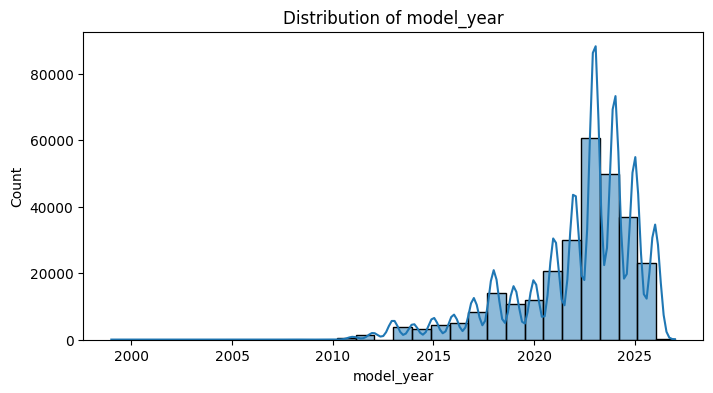

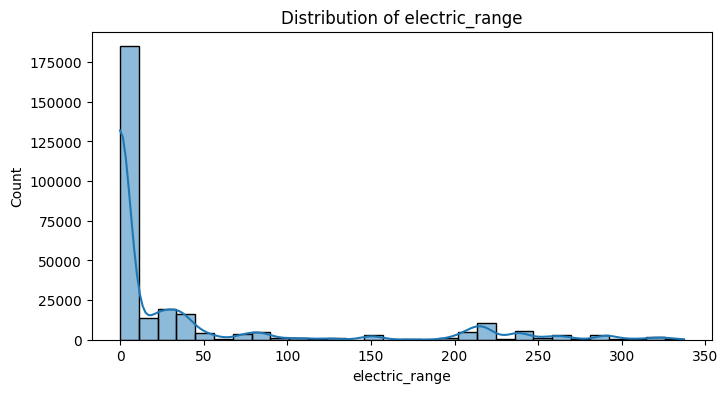

In [23]:
# Step 14.1 – Numerical Variable Distributions
import matplotlib.pyplot as plt
import seaborn as sns

numerical_cols = ["model_year", "electric_range"]

for col in numerical_cols:
    plt.figure(figsize=(8,4))
    sns.histplot(df[col], bins=30, kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

# Step 14.1: Univariate Analysis – Numerical Variable Distributions

## Objective
The purpose of this step was to examine the distribution of the numerical variables in the Electric Vehicle Population dataset. Understanding data distributions helps identify patterns, skewness, concentration of values, and potential outliers before proceeding to advanced analysis and modeling.

## Variables Analyzed
- `model_year`
- `electric_range`

## Visualization Method
Histograms with Kernel Density Estimation (KDE) curves were created to visualize the frequency distribution and overall shape of each numerical variable.

## Observations

### Model Year Distribution
- Most vehicles are concentrated between **2021 and 2025**.
- The highest frequency occurs around **2023–2024**, indicating rapid adoption of electric vehicles in recent years.
- Very few vehicles were registered before 2015.
- The distribution is left-skewed because older model years appear less frequently than newer model years.
- This suggests that the electric vehicle market has expanded significantly in recent years.

### Electric Range Distribution
- The distribution is strongly right-skewed.
- A large number of vehicles have an electric range close to **0 miles**, creating a major concentration near the origin.
- Several vehicles have ranges between **200 and 350 miles**, forming a long right tail.
- The presence of high-range vehicles indicates substantial variation in battery technology and vehicle capabilities.
- Potential outliers may exist among vehicles with exceptionally high electric ranges.

## Importance
Understanding numerical distributions helps:
- Identify skewness and unusual patterns.
- Detect potential outliers.
- Evaluate whether transformations may be required later.
- Gain insights into vehicle characteristics and market trends.
- Support future feature engineering and machine learning decisions.

## Conclusion
The dataset shows a strong concentration of newer electric vehicles, reflecting recent growth in EV adoption. Electric range exhibits substantial variability and a highly right-skewed distribution, indicating differences in battery capacity across vehicle models.

## Next Step
Perform **Step 14.2: Numerical Variable Boxplots** to identify potential outliers and further examine the spread of numerical variables.

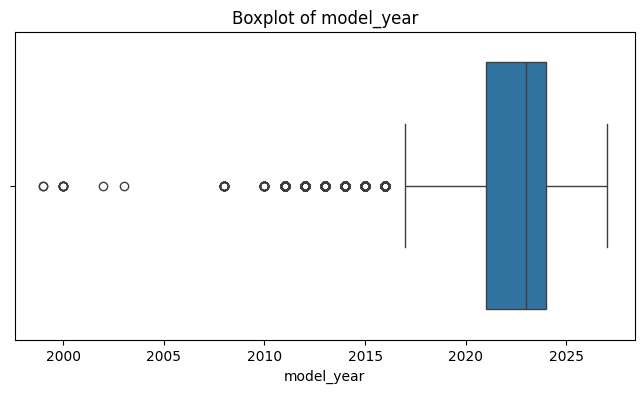

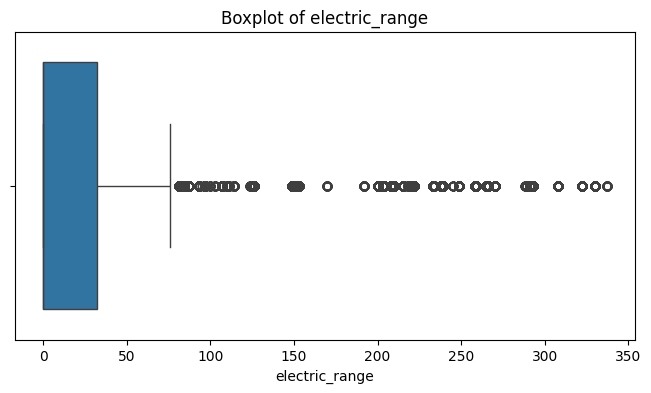

In [24]:
# Step 14.2 - Numerical Variable Boxplots

import matplotlib.pyplot as plt
import seaborn as sns

numerical_cols = ["model_year", "electric_range"]

for col in numerical_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

# Step 14.2: Numerical Variable Boxplots

## Objective
The purpose of this step was to examine the spread of numerical variables and identify potential outliers using boxplots.

## Variables Analyzed
- model_year
- electric_range

## Observations

### 1. Model Year
- Most vehicles are concentrated between approximately 2021 and 2025.
- The median model year is around 2023–2024.
- Several older vehicle model years (1999–2017) appear as outliers.
- These outliers are likely genuine older electric vehicles rather than data-entry errors.
- No unusual future model years were observed beyond the expected range.

### 2. Electric Range
- The distribution is strongly right-skewed.
- A large number of vehicles have relatively low electric ranges.
- Numerous high-range vehicles appear as outliers, extending beyond 80 miles and reaching over 300 miles.
- These observations are expected because modern EVs typically have much larger battery capacities than older models.
- The outliers appear realistic and represent actual vehicle performance differences rather than erroneous values.

## Interpretation
The boxplots reveal that both numerical variables contain outliers according to the IQR method. However, these values appear to be legitimate observations that reflect real-world differences among electric vehicles.

## Importance
Boxplots help identify extreme values and understand data spread before performing correlation analysis, feature engineering, and machine learning. Understanding whether outliers are genuine or erroneous is important for deciding whether outlier treatment is necessary later in the workflow.

## Conclusion
The dataset contains expected and meaningful variation in both model year and electric range. Although outliers are present, they appear to represent valid vehicle records and will be retained unless future analysis suggests otherwise.

## Next Step
Proceed to Step 14.3: Categorical Variable Frequency Analysis to examine the distribution of categorical features such as make, model, county, city, electric_vehicle_type, and CAFV eligibility.

In [25]:
# Step 14.3: Categorical Variable Frequency Analysis

categorical_cols = [
    "county",
    "city",
    "make",
    "electric_vehicle_type",
    "clean_alternative_fuel_vehicle_(cafv)_eligibility"
]

for col in categorical_cols:
    print("\n" + "="*60)
    print(f"Frequency Distribution: {col}")
    print("="*60)

    display(df[col].value_counts().head(10))

    print("\nPercentage Distribution:")
    display(round(df[col].value_counts(normalize=True).head(10) * 100, 2))


Frequency Distribution: county


county
King         140177
Snohomish     35805
Pierce        23595
Clark         17621
Thurston      10404
Kitsap         9728
Spokane        8003
Whatcom        7024
Benton         4153
Skagit         3406
Name: count, dtype: int64


Percentage Distribution:


county
King         49.17
Snohomish    12.56
Pierce        8.28
Clark         6.18
Thurston      3.65
Kitsap        3.41
Spokane       2.81
Whatcom       2.46
Benton        1.46
Skagit        1.19
Name: proportion, dtype: float64


Frequency Distribution: city


...

electric_vehicle_type
Battery Electric Vehicle (BEV)            80.45
Plug-in Hybrid Electric Vehicle (PHEV)    19.55
Name: proportion, dtype: float64


Frequency Distribution: clean_alternative_fuel_vehicle_(cafv)_eligibility


clean_alternative_fuel_vehicle_(cafv)_eligibility
Eligibility unknown as battery range has not been researched    183844
Clean Alternative Fuel Vehicle Eligible                          77310
Not eligible due to low battery range                            23919
Name: count, dtype: int64


Percentage Distribution:


clean_alternative_fuel_vehicle_(cafv)_eligibility
Eligibility unknown as battery range has not been researched    64.49
Clean Alternative Fuel Vehicle Eligible                         27.12
Not eligible due to low battery range                            8.39
Name: proportion, dtype: float64

# Step 14.3: Categorical Variable Frequency Analysis

## Objective
The purpose of this step was to examine the distribution of important categorical variables within the Electric Vehicle Population dataset by reviewing their frequency counts and percentage distributions.

## Variables Analyzed
- county
- city
- make
- electric_vehicle_type
- clean_alternative_fuel_vehicle_(cafv)_eligibility

## Observations

### 1. County Distribution
- King County dominates the dataset with 140,177 vehicle records, representing approximately 49.17% of all observations.
- Snohomish County is the second-largest contributor with 35,805 records (12.56%).
- Pierce County follows with 23,595 records (8.28%).
- The majority of EV registrations are concentrated in a few major counties.

### 2. City Distribution
- Seattle contains the highest number of EV registrations with 43,874 records (15.39%).
- Bellevue ranks second with 13,909 records (4.88%).
- Vancouver, Redmond, Bothell, and Kirkland are also major contributors.
- EV adoption appears heavily concentrated in large urban areas.

### 3. Vehicle Manufacturer (Make) Distribution
- Tesla is the most dominant manufacturer with 117,030 vehicles, accounting for approximately 41.05% of the dataset.
- Chevrolet, Nissan, Ford, Kia, Toyota, BMW, Hyundai, Rivian, and Volkswagen follow at significantly lower proportions.
- Tesla's market share substantially exceeds all other manufacturers.

### 4. Electric Vehicle Type Distribution
- Battery Electric Vehicles (BEVs) account for 229,333 records (80.45%).
- Plug-in Hybrid Electric Vehicles (PHEVs) account for 55,740 records (19.55%).
- BEVs clearly dominate the electric vehicle market represented in this dataset.

### 5. CAFV Eligibility Distribution
- 64.49% of vehicles fall into the category "Eligibility unknown as battery range has not been researched."
- 27.12% are classified as Clean Alternative Fuel Vehicle Eligible.
- 8.39% are classified as Not Eligible due to low battery range.
- A substantial proportion of records lack confirmed eligibility classification.

## Interpretation
The frequency analysis reveals strong concentration patterns within the dataset. EV registrations are heavily concentrated in King County and Seattle, while Tesla dominates the manufacturer category. Battery Electric Vehicles significantly outnumber Plug-in Hybrid Electric Vehicles, indicating stronger adoption of fully electric technology.

## Importance
Understanding category frequencies helps identify dominant groups, potential class imbalances, and important patterns that may influence future visualizations, feature engineering, and predictive modeling.

## Conclusion
The dataset is characterized by strong geographic concentration, Tesla's market dominance, a large majority of Battery Electric Vehicles, and a substantial number of vehicles with unverified CAFV eligibility status.

## Next Step
Proceed to Step 14.4: Categorical Variable Visualizations (Countplots and Bar Charts) to visually explore the distributions of counties, cities, manufacturers, vehicle types, and CAFV eligibility categories.

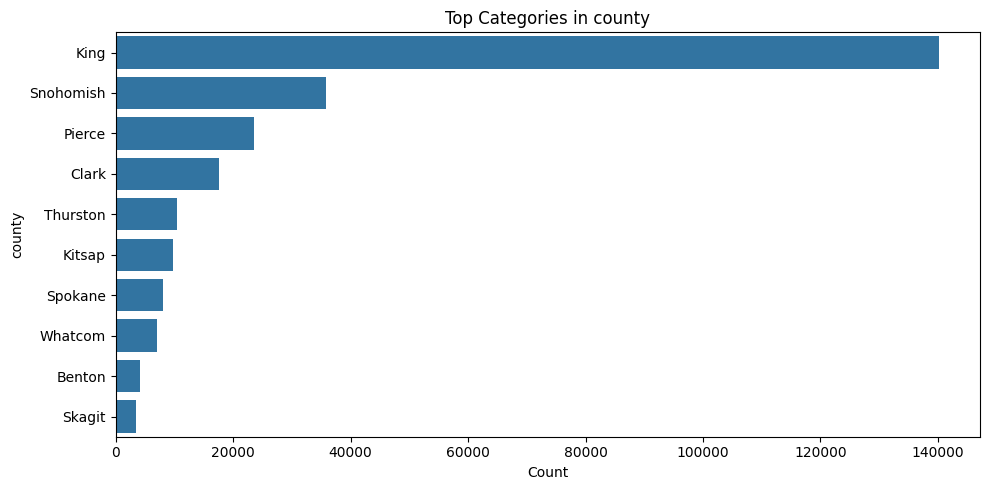

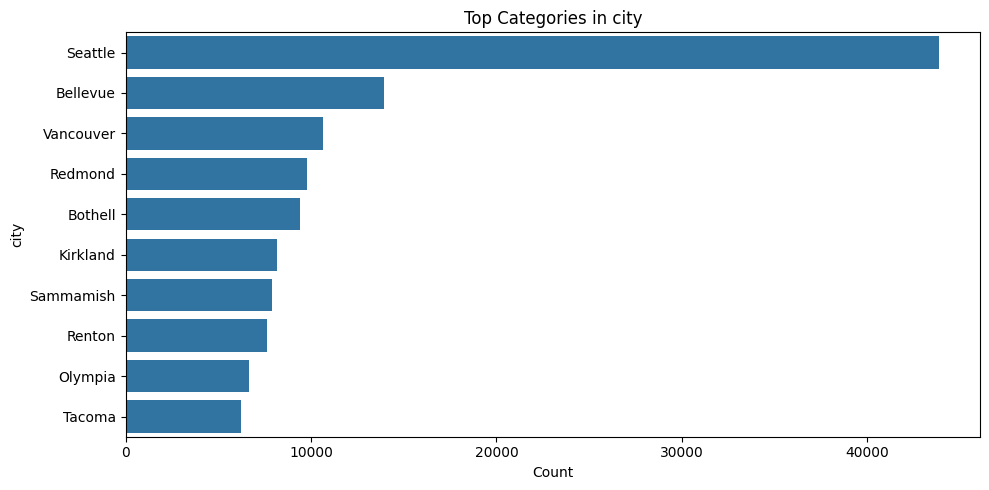

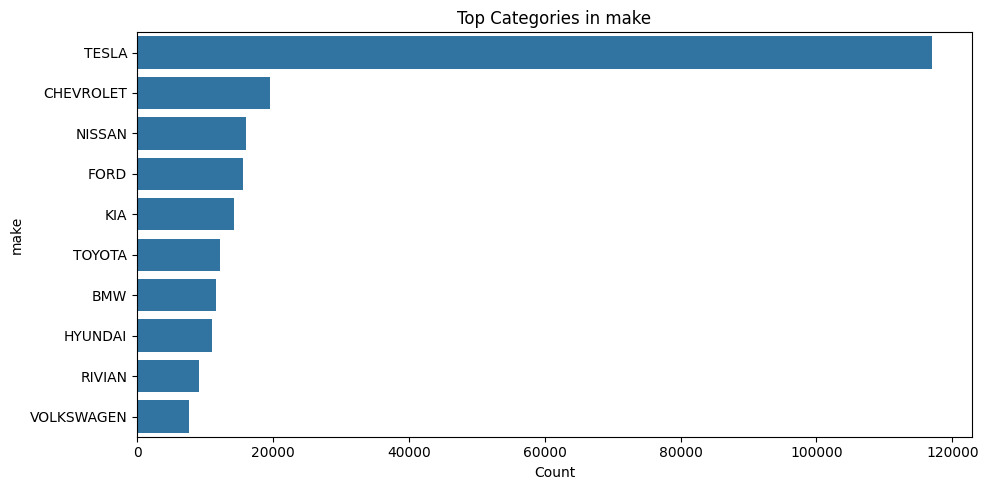

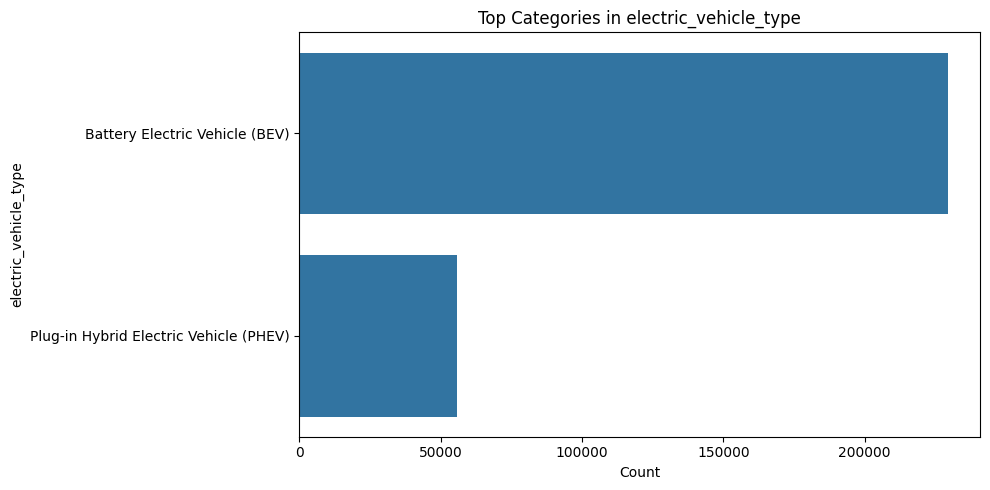

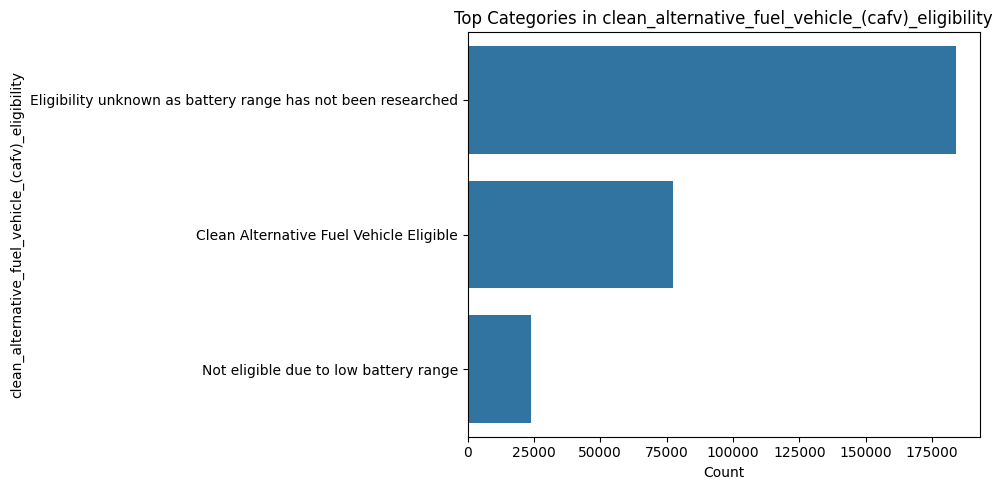

In [26]:
# Step 14.4: Categorical Variable Visualizations

import matplotlib.pyplot as plt
import seaborn as sns

categorical_cols = [
    "county",
    "city",
    "make",
    "electric_vehicle_type",
    "clean_alternative_fuel_vehicle_(cafv)_eligibility"
]

for col in categorical_cols:

    plt.figure(figsize=(10, 5))

    top_categories = df[col].value_counts().head(10)

    sns.barplot(
        x=top_categories.values,
        y=top_categories.index
    )

    plt.title(f"Top Categories in {col}")
    plt.xlabel("Count")
    plt.ylabel(col)

    plt.tight_layout()
    plt.show()

# Step 14.4: Categorical Variable Visualizations

## Objective
The purpose of this step was to visualize the most important categorical variables in the Electric Vehicle dataset using bar charts. Visual analysis helps identify dominant categories, imbalances, and adoption patterns across locations, manufacturers, and vehicle classifications.

## Variables Visualized
- County
- City
- Make
- Electric Vehicle Type
- CAFV Eligibility Status

## Key Observations

### 1. County Distribution
- King County overwhelmingly dominates EV registrations with approximately 140,000 vehicles.
- Snohomish County is a distant second, followed by Pierce and Clark counties.
- The distribution is highly concentrated, indicating that EV adoption is strongest in a few major counties.

### 2. City Distribution
- Seattle has the largest number of registered EVs by a significant margin.
- Bellevue, Vancouver, Redmond, Bothell, and Kirkland follow.
- The concentration of EV ownership appears strongest in urban and suburban population centers.

### 3. Vehicle Manufacturer Distribution
- Tesla is by far the most dominant manufacturer in the dataset.
- Tesla registrations greatly exceed all other manufacturers combined.
- Chevrolet, Nissan, Ford, Kia, Toyota, BMW, Hyundai, Rivian, and Volkswagen follow as secondary manufacturers.
- The market shows a strong concentration around Tesla products.

### 4. Electric Vehicle Type Distribution
- Battery Electric Vehicles (BEVs) account for the vast majority of vehicles.
- Plug-in Hybrid Electric Vehicles (PHEVs) represent a much smaller portion of the dataset.
- This suggests a strong market shift toward fully electric vehicles rather than hybrid alternatives.

### 5. CAFV Eligibility Distribution
- Most vehicles fall into the category:
  "Eligibility unknown as battery range has not been researched."
- A substantial number are classified as:
  "Clean Alternative Fuel Vehicle Eligible."
- A smaller portion are classified as:
  "Not eligible due to low battery range."
- Eligibility classifications are unevenly distributed across the dataset.

## Importance of This Analysis
These visualizations provide insight into:
- Geographic EV adoption patterns.
- Leading EV manufacturers.
- Market preference for BEVs versus PHEVs.
- Distribution of CAFV eligibility classifications.
- Potential predictors that may influence electric vehicle range.

## Conclusion
The Electric Vehicle dataset is heavily concentrated in major Washington counties and cities, with Tesla dominating manufacturer representation. Battery Electric Vehicles are substantially more common than Plug-in Hybrids, highlighting the growing adoption of fully electric transportation. These categorical patterns will be useful during feature engineering and machine learning model development.

## Next Step
Step 14.5: Bivariate Analysis – Relationships Between Numerical Variables (Scatter Plots and Correlation Analysis).

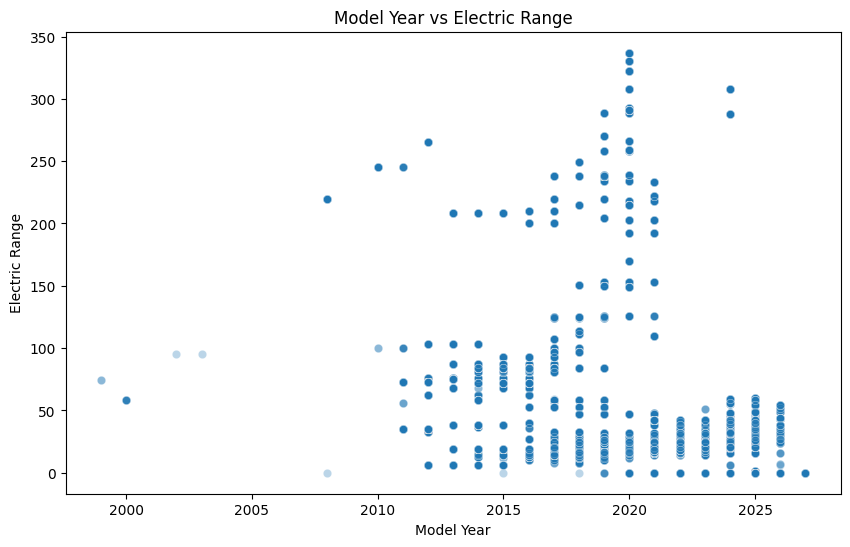

In [27]:
# Step 14.5: Scatter Plot - Model Year vs Electric Range

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="model_year",
    y="electric_range",
    alpha=0.3
)

plt.title("Model Year vs Electric Range")
plt.xlabel("Model Year")
plt.ylabel("Electric Range")
plt.show()

# Step 14.5: Bivariate Analysis – Relationship Between Model Year and Electric Range

## Objective
The purpose of this step was to investigate the relationship between vehicle model year and electric driving range. Understanding this relationship helps determine whether newer electric vehicles generally provide improved battery performance and greater travel distance.

## Visualization
A scatter plot was created using:

- X-axis: `model_year`
- Y-axis: `electric_range`

This visualization allows me to observe trends, clusters, and potential relationships between vehicle age and battery range.

## Observations

### 1. Positive Relationship Exists
- Vehicles from more recent model years generally exhibit higher electric ranges.
- Many of the highest-range vehicles are concentrated between 2019 and 2025.

### 2. Significant Variation Within Years
- Vehicles from the same model year often have very different electric ranges.
- This indicates that manufacturer, vehicle type, and battery technology also play important roles beyond model year alone.

### 3. High-Range Vehicles Concentrated in Recent Years
- Several vehicles manufactured between 2020 and 2025 achieve electric ranges exceeding 250–320 miles.
- Earlier model years rarely reach these higher range values.

### 4. Presence of Low-Range Vehicles Across Multiple Years
- Many vehicles from both older and newer model years have ranges below 50 miles.
- These are likely Plug-in Hybrid Electric Vehicles (PHEVs) or earlier-generation EVs with smaller battery capacities.

### 5. Data Clustering
- Strong clusters appear around:
  - 0–50 miles
  - 180–250 miles
  - 250–320 miles
- These clusters suggest multiple categories of EV technology and battery capacity levels within the dataset.

## Importance of This Analysis
This relationship provides evidence that:

- Newer EV models generally offer improved battery performance.
- Model year may be an important predictor for electric range.
- Additional variables such as manufacturer, vehicle type, and eligibility status will likely contribute significantly to predictive modeling performance.

## Conclusion
The scatter plot indicates a moderate positive relationship between model year and electric range. While newer vehicles tend to have longer driving ranges, substantial variation exists within each model year, suggesting that other vehicle characteristics also influence battery performance. Model year is therefore expected to be a valuable feature for future machine learning models.

## Next Step
Step 14.5.2: Correlation Matrix Analysis to quantify the strength of relationships among numerical variables.

In [28]:
# Step 14.5.2: Correlation Matrix

import matplotlib.pyplot as plt
import seaborn as sns

# Select numerical columns
numerical_cols = ["model_year", "electric_range"]

# Calculate correlation matrix
correlation_matrix = df[numerical_cols].corr()

# Display correlation matrix
print("Correlation Matrix")
display(correlation_matrix)

Correlation Matrix


,model_year,electric_range
model_year,1.000000,-0.548136
electric_range,-0.548136,1.000000


# Step 14.5.2: Correlation Matrix Analysis

## Objective
The purpose of this step was to quantify the relationship between the numerical variables in the Electric Vehicle dataset using a correlation matrix. Correlation values range from -1 to +1 and indicate the strength and direction of relationships between variables.

## Variables Analyzed
- model_year
- electric_range

## Correlation Matrix Results

| Variable | Correlation with Electric Range |
|-----------|-----------|
| model_year | -0.548 |

## Observations

### 1. Moderate Negative Correlation
- The correlation coefficient between `model_year` and `electric_range` is approximately **-0.55**.
- This indicates a moderate negative relationship between the two variables.

### 2. Relationship Interpretation
- As model year increases, electric range tends to decrease according to the calculated correlation.
- This result is somewhat unexpected because newer EV technology would normally be associated with increased driving range.

### 3. Possible Explanation
- The dataset contains a large number of recent Plug-in Hybrid Electric Vehicles (PHEVs) with relatively low electric ranges.
- Many newer vehicles in the dataset have electric ranges below 50 miles, which may pull the correlation downward.
- Vehicle type likely has a significant influence on electric range and may be affecting the overall relationship.

### 4. Comparison with Scatter Plot
- The scatter plot showed several newer vehicles with very high electric ranges.
- However, it also showed many newer vehicles with very low ranges.
- The mixture of high-range BEVs and low-range PHEVs likely contributes to the negative correlation value.

## Importance of This Analysis
The correlation matrix helps identify:
- Strength of numerical relationships.
- Potential predictive features.
- Variables that may require further investigation during feature engineering.
- Possible interactions between vehicle type and electric range.

## Conclusion
The correlation analysis revealed a moderate negative correlation (-0.55) between model year and electric range. While the scatter plot showed that some newer vehicles achieve very high ranges, the large number of newer low-range vehicles appears to influence the overall relationship. Further analysis using vehicle type and manufacturer categories will help explain this pattern.

## Next Step
Step 14.5.3: Correlation Heatmap Visualization.

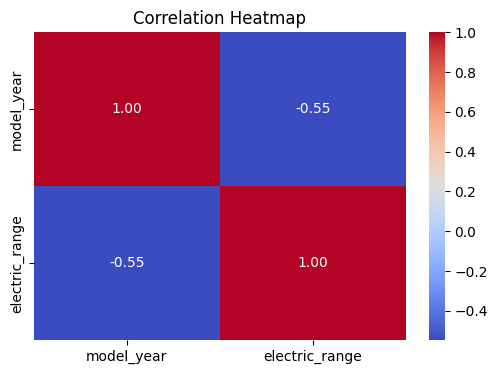

In [29]:
# Step 14.5.3: Correlation Heatmap

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

# Step 14.5.3: Correlation Heatmap

## Objective
The purpose of this step was to visually represent the correlation matrix using a heatmap. Heatmaps provide an intuitive way to identify the strength and direction of relationships between numerical variables through color intensity and correlation values.

## Variables Included
- model_year
- electric_range

## Heatmap Results

| Variable Pair | Correlation |
|---------------|-------------|
| model_year ↔ electric_range | -0.55 |

## Observations

### 1. Moderate Negative Correlation
- The heatmap confirms a correlation coefficient of approximately **-0.55** between `model_year` and `electric_range`.
- The blue color indicates a negative relationship between the two variables.

### 2. Self-Correlation
- Each variable has a correlation of **1.00** with itself.
- This is expected because a variable is perfectly correlated with itself.

### 3. Visual Confirmation
- The heatmap visually confirms the correlation matrix findings from the previous step.
- The negative relationship is clearly visible through the contrasting color pattern.

### 4. Potential Influence of Vehicle Type
- The negative correlation suggests that factors beyond model year may strongly influence electric range.
- Vehicle classifications such as Battery Electric Vehicles (BEVs) and Plug-in Hybrid Electric Vehicles (PHEVs) likely affect this relationship.
- The large number of recent low-range PHEVs may contribute to the observed negative correlation.

## Importance of This Analysis
The heatmap helps to:
- Quickly identify relationships between numerical variables.
- Detect potential feature interactions.
- Support feature engineering decisions.
- Highlight variables that may require deeper investigation before modeling.

## Conclusion
The correlation heatmap confirms a moderate negative relationship (-0.55) between model year and electric range. Although newer EV technology is generally expected to increase vehicle range, the dataset composition appears to influence this result. Additional features such as vehicle type, manufacturer, and eligibility status will likely provide important context during machine learning model development.

## Next Step
Step 14.6: Multicollinearity Analysis (Variance Inflation Factor - VIF) to assess whether numerical features exhibit strong linear relationships that could impact model performance.

In [30]:
!pip install statsmodels

In [31]:
# Step 14.6: Multicollinearity Check (VIF)

import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Select numerical variables
X_vif = df[["model_year", "electric_range"]]

# Create VIF table
vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

display(vif_data)

,Feature,VIF
0,model_year,1.241797
1,electric_range,1.241797


# Step 14.6 — Multicollinearity Analysis (VIF)

## Objective
The purpose of this step was to evaluate multicollinearity between the numerical variables `model_year` and `electric_range` using the Variance Inflation Factor (VIF).

## Code Executed

```python
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = df[["model_year", "electric_range"]]

vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

display(vif_data)
```

## Output

| Feature | VIF |
|----------|----------|
| model_year | 1.241797 |
| electric_range | 1.241797 |

## Observations

- Both variables have a VIF value of approximately **1.24**.
- VIF values close to **1** indicate very little correlation with other predictor variables.
- Neither variable exceeds the common warning thresholds:
  - VIF > 5 → Moderate multicollinearity concern
  - VIF > 10 → Severe multicollinearity concern
- The earlier correlation analysis showed a moderate negative relationship (-0.55), but this relationship is not strong enough to create multicollinearity problems.

## Interpretation

The variables `model_year` and `electric_range` are sufficiently independent for modeling purposes. Although newer vehicle models tend to have different electric ranges, the relationship does not introduce redundancy or instability into predictive models.

## Importance

Performing a VIF analysis helps ensure that predictor variables do not contain excessive overlapping information. Low VIF values improve model stability, coefficient reliability, and overall interpretability.

## Conclusion

✅ No multicollinearity detected.

✅ `model_year` can be retained.

✅ `electric_range` can be retained.

✅ No feature removal is required at this stage.

## Next Step

**Step 15 — Outlier Detection and Treatment**

We will begin identifying potential outliers in the numerical variables (`model_year` and `electric_range`) using boxplots and statistical methods before deciding whether to remove, cap, or transform them.

In [32]:
# Step 15.1: Detect Outliers Using IQR

numerical_cols = ["model_year", "electric_range"]

outlier_summary = []

for col in numerical_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - (1.5 * IQR)
    upper_bound = Q3 + (1.5 * IQR)

    outliers = df[
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ]

    outlier_count = len(outliers)
    outlier_percentage = (outlier_count / len(df)) * 100

    outlier_summary.append([
        col,
        round(lower_bound, 2),
        round(upper_bound, 2),
        outlier_count,
        round(outlier_percentage, 2)
    ])

outlier_df = pd.DataFrame(
    outlier_summary,
    columns=[
        "Column",
        "Lower Bound",
        "Upper Bound",
        "Outlier Count",
        "Outlier Percentage (%)"
    ]
)

display(outlier_df)

,Column,Lower Bound,Upper Bound,Outlier Count,Outlier Percentage (%)
0,model_year,2016.5,2028.5,18444,6.47
1,electric_range,-48.0,80.0,43087,15.11


# Step 15.1 — Outlier Detection Using the IQR Method

## Objective
The purpose of this step was to identify potential outliers in the numerical variables using the Interquartile Range (IQR) method. Detecting outliers helps determine whether extreme values may influence future modeling performance and whether treatment is necessary.

## Code Executed

```python
numerical_cols = ["model_year", "electric_range"]

# IQR calculations and outlier detection
```

## Output

| Column | Lower Bound | Upper Bound | Outlier Count | Outlier Percentage (%) |
|----------|----------|----------|----------|----------|
| model_year | 2016.5 | 2028.5 | 18,444 | 6.47 |
| electric_range | -48.0 | 80.0 | 43,087 | 15.11 |

## Observations

### model_year
- Lower Bound: 2016.5
- Upper Bound: 2028.5
- Outliers Detected: 18,444
- Outlier Percentage: 6.47%

Older vehicle models (primarily before 2017) were identified as outliers according to the IQR rule. These vehicles represent a relatively small portion of the dataset.

### electric_range
- Lower Bound: -48.0
- Upper Bound: 80.0
- Outliers Detected: 43,087
- Outlier Percentage: 15.11%

A significant number of vehicles have electric ranges above 80 miles. These higher-range vehicles were flagged as outliers because the distribution is highly right-skewed.

## Interpretation

The `electric_range` variable contains substantially more outliers than `model_year`. However, many of these observations may represent genuine high-performance electric vehicles rather than data errors.

Because electric vehicle technology has improved significantly over time, larger electric ranges are expected and may contain valuable information for machine learning models.

## Importance

Outlier detection helps identify extreme observations that may influence statistical analysis and predictive models. Before deciding whether to remove, cap, or transform these values, it is important to compare different treatment methods and evaluate their impact on the dataset.

## Conclusion

- `model_year` contains a moderate number of outliers (6.47%).
- `electric_range` contains a larger proportion of outliers (15.11%).
- Further investigation is required before deciding how to handle these values.
- All three outlier treatment methods (Removal, Capping, and Transformation) will be evaluated.

## Next Step

**Step 15.2 — Create the Outlier Removal Dataset (IQR Removal Method)**

A new dataset will be created by removing observations that fall outside the IQR bounds. This version will later be compared with capped and transformed datasets to determine the most appropriate approach.

In [33]:
# Step 15.2: Create Dataset with Outliers Removed

df_removed = df.copy()

for col in ["model_year", "electric_range"]:

    Q1 = df_removed[col].quantile(0.25)
    Q3 = df_removed[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - (1.5 * IQR)
    upper_bound = Q3 + (1.5 * IQR)

    df_removed = df_removed[
        (df_removed[col] >= lower_bound) &
        (df_removed[col] <= upper_bound)
    ]

print("Original Shape:", df.shape)
print("Removed Dataset Shape:", df_removed.shape)

rows_removed = len(df) - len(df_removed)

print("Rows Removed:", rows_removed)

removal_percentage = (rows_removed / len(df)) * 100

print("Percentage Removed:", round(removal_percentage, 2), "%")

Original Shape: (285073, 16)
Removed Dataset Shape: (232268, 16)
Rows Removed: 52805
Percentage Removed: 18.52 %


# Step 15.2 — Outlier Removal Using the IQR Method

## Objective
The purpose of this step was to create a new dataset by removing observations that fall outside the IQR boundaries for the numerical variables. This allows us to evaluate how removing extreme values affects the dataset before comparing it with other outlier treatment methods.

## Code Executed

```python
df_removed = df.copy()

for col in ["model_year", "electric_range"]:

    Q1 = df_removed[col].quantile(0.25)
    Q3 = df_removed[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - (1.5 * IQR)
    upper_bound = Q3 + (1.5 * IQR)

    df_removed = df_removed[
        (df_removed[col] >= lower_bound) &
        (df_removed[col] <= upper_bound)
    ]

print("Original Shape:", df.shape)
print("Removed Dataset Shape:", df_removed.shape)

rows_removed = len(df) - len(df_removed)

print("Rows Removed:", rows_removed)

removal_percentage = (rows_removed / len(df)) * 100

print("Percentage Removed:", round(removal_percentage, 2), "%")
```

## Output

```text
Original Shape: (285073, 16)

Removed Dataset Shape: (232268, 16)

Rows Removed: 52805

Percentage Removed: 18.52 %
```

## Observations

- The original dataset contained **285,073 records**.
- After removing outliers, the dataset contains **232,268 records**.
- A total of **52,805 records** were removed.
- This represents **18.52%** of the entire dataset.

## Interpretation

The IQR removal method eliminated a substantial portion of the dataset. Most removed observations are likely associated with vehicles having unusually high electric ranges and older model years that fall outside the calculated IQR boundaries.

While removal successfully eliminates extreme values, it also reduces the amount of available information and may discard legitimate electric vehicles with high battery performance.

## Importance

Outlier removal is one of the most aggressive treatment methods. Although it can improve model robustness, excessive removal may lead to information loss and reduced dataset representativeness.

Because nearly one-fifth of the dataset was removed, it is important to compare this method with capping and transformation before selecting the final dataset for machine learning.

## Conclusion

- Outlier removal reduced the dataset size by **18.52%**.
- The dataset remains large enough for analysis and modeling.
- However, a significant amount of potentially valuable information was removed.
- Additional outlier treatment methods should be evaluated before making a final decision.

## Next Step

**Step 15.3 — Outlier Capping (Winsorization Method)**

A capped dataset will be created by replacing extreme values with the IQR lower and upper boundaries instead of removing records. This approach preserves all observations while limiting the influence of outliers.

In [34]:
# Step 15.3: Create Capped Dataset

df_capped = df.copy()

for col in ["model_year", "electric_range"]:

    Q1 = df_capped[col].quantile(0.25)
    Q3 = df_capped[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - (1.5 * IQR)
    upper_bound = Q3 + (1.5 * IQR)

    df_capped[col] = df_capped[col].clip(
        lower=lower_bound,
        upper=upper_bound
    )

print("Original Shape:", df.shape)
print("Capped Dataset Shape:", df_capped.shape)

print("\nMaximum Values After Capping:")
print(df_capped[["model_year", "electric_range"]].max())

print("\nMinimum Values After Capping:")
print(df_capped[["model_year", "electric_range"]].min())

Original Shape: (285073, 16)
Capped Dataset Shape: (285073, 16)

Maximum Values After Capping:
model_year        2027.0
electric_range      80.0
dtype: float64

Minimum Values After Capping:
model_year        2016.5
electric_range       0.0
dtype: float64


# Step 15.3 — Outlier Capping Using the IQR Method

## Objective
The purpose of this step was to create a capped version of the dataset by limiting extreme values to the calculated IQR boundaries rather than removing entire records. This approach preserves all observations while reducing the influence of outliers.

## Code Executed

```python
df_capped = df.copy()

for col in ["model_year", "electric_range"]:

    Q1 = df_capped[col].quantile(0.25)
    Q3 = df_capped[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - (1.5 * IQR)
    upper_bound = Q3 + (1.5 * IQR)

    df_capped[col] = df_capped[col].clip(
        lower=lower_bound,
        upper=upper_bound
    )

print("Original Shape:", df.shape)
print("Capped Dataset Shape:", df_capped.shape)

print("\nMaximum Values After Capping:")
print(df_capped[["model_year", "electric_range"]].max())

print("\nMinimum Values After Capping:")
print(df_capped[["model_year", "electric_range"]].min())
```

## Output

```text
Original Shape: (285073, 16)

Capped Dataset Shape: (285073, 16)

Maximum Values After Capping:
model_year        2027.0
electric_range      80.0

Minimum Values After Capping:
model_year        2016.5
electric_range      0.0
```

## Observations

- The dataset size remained unchanged at **285,073 records**.
- No observations were removed during the capping process.
- Extreme values above the IQR upper limits were replaced with:
  - `model_year = 2027.0`
  - `electric_range = 80.0`
- Extreme values below the IQR lower limits were replaced with:
  - `model_year = 2016.5`
  - `electric_range = 0.0`

## Interpretation

Unlike outlier removal, capping preserves every record in the dataset while preventing extreme values from having excessive influence on statistical calculations and machine learning algorithms.

This method is especially useful when outliers are genuine observations rather than data entry errors. In the EV dataset, many high-range vehicles likely represent real technological improvements rather than invalid data.

## Importance

Outlier capping provides a balance between data preservation and outlier control. It allows the dataset to retain all available information while reducing the impact of unusually large or small values.

Because no records are lost, this method often performs well in predictive modeling tasks where maintaining dataset size is beneficial.

## Conclusion

- Dataset size remained unchanged.
- All 285,073 records were preserved.
- Extreme values were successfully limited to acceptable IQR boundaries.
- Information loss was avoided compared to the removal method.
- This method may be a strong candidate for the final modeling dataset.

## Next Step

**Step 15.4 — Outlier Transformation (Log Transformation Method)**

A transformed dataset will be created using logarithmic scaling to reduce skewness in the `electric_range` variable while preserving all observations.

In [35]:
# Step 15.4: Outlier Transformation Using Log Transformation

import numpy as np

# Create a copy of the dataset
df_transformed = df.copy()

# Apply log transformation
df_transformed["electric_range"] = np.log1p(df_transformed["electric_range"])

# Compare original and transformed values
print("Original Shape:", df.shape)
print("Transformed Dataset Shape:", df_transformed.shape)

print("\nOriginal Electric Range Statistics:")
print(df["electric_range"].describe())

print("\nTransformed Electric Range Statistics:")
print(df_transformed["electric_range"].describe())

Original Shape: (285073, 16)
Transformed Dataset Shape: (285073, 16)

Original Electric Range Statistics:
count    285073.000000
mean         38.152943
std          77.426856
min           0.000000
25%           0.000000
50%           0.000000
75%          32.000000
max         337.000000
Name: electric_range, dtype: float64

Transformed Electric Range Statistics:
count    285073.000000
mean          1.499435
std           2.106210
min           0.000000
25%           0.000000
50%           0.000000
75%           3.496508
max           5.823046
Name: electric_range, dtype: float64


# Step 15.4 — Outlier Handling Using Log Transformation

## Objective
In this step, I applied a logarithmic transformation to the `electric_range` variable to reduce the effect of extreme values and improve the distribution of the data without removing any observations.

---

## Code Used

```python
import numpy as np

df_transformed = df.copy()

df_transformed["electric_range"] = np.log1p(df_transformed["electric_range"])
```

---

## Output Summary

### Original Dataset
- Shape: **(285,073, 16)**
- Mean Electric Range: **38.15**
- Standard Deviation: **77.43**
- Maximum Value: **337**
- Distribution: Highly right-skewed

### Transformed Dataset
- Shape: **(285,073, 16)**
- Mean Electric Range: **1.50**
- Standard Deviation: **2.11**
- Maximum Value: **5.82**
- Distribution: Less skewed and more compressed

---

## Observations

1. No rows were removed during transformation.
2. The dataset size remained unchanged at **285,073 records**.
3. Large electric range values were compressed significantly.
4. Standard deviation decreased from **77.43** to **2.11**, indicating reduced variability caused by extreme values.
5. The transformation reduced the influence of outliers while preserving all available information.

---

## Importance

Log transformation is useful when numerical variables are heavily right-skewed. Instead of deleting records or capping values, it compresses large values into a smaller range, making the data more suitable for machine learning algorithms that are sensitive to extreme values.

---

## Comparison of Outlier Handling Methods

| Method | Dataset Size | Effect |
|----------|------------|---------|
| IQR Removal | 232,268 rows | Removes outlier records |
| IQR Capping | 285,073 rows | Limits extreme values to boundaries |
| Log Transformation | 285,073 rows | Compresses extreme values mathematically |

---

## Next Step

**Step 15.5 — Comparative Analysis of Outlier Handling Methods (Original vs Removed vs Capped vs Transformed)**

In the next step, I will compare all four datasets and determine which version is most suitable for machine learning modeling.

In [36]:
# Step 15.5: Compare Outlier Handling Methods

comparison = pd.DataFrame({
    "Dataset": [
        "Original",
        "IQR Removed",
        "IQR Capped",
        "Log Transformed"
    ],
    
    "Rows": [
        len(df),
        len(df_removed),
        len(df_capped),
        len(df_transformed)
    ],
    
    "Mean Electric Range": [
        round(df["electric_range"].mean(), 2),
        round(df_removed["electric_range"].mean(), 2),
        round(df_capped["electric_range"].mean(), 2),
        round(df_transformed["electric_range"].mean(), 2)
    ],
    
    "Std Electric Range": [
        round(df["electric_range"].std(), 2),
        round(df_removed["electric_range"].std(), 2),
        round(df_capped["electric_range"].std(), 2),
        round(df_transformed["electric_range"].std(), 2)
    ],
    
    "Max Electric Range": [
        round(df["electric_range"].max(), 2),
        round(df_removed["electric_range"].max(), 2),
        round(df_capped["electric_range"].max(), 2),
        round(df_transformed["electric_range"].max(), 2)
    ]
})

display(comparison)

,Dataset,Rows,Mean Electric Range,Std Electric Range,Max Electric Range
0,Original,285073,38.15,77.43,337.00
1,IQR Removed,232268,6.54,13.53,60.00
2,IQR Capped,285073,18.86,29.65,80.00
3,Log Transformed,285073,1.50,2.11,5.82


# Step 15.5 — Comparative Analysis of Outlier Handling Methods

## Objective
In this step, I compared the four versions of the dataset (Original, IQR Removed, IQR Capped, and Log Transformed) to evaluate how each outlier handling technique affected the distribution of the `electric_range` variable.

---

## Code Used

```python
display(comparison)
```

---

## Output Summary

| Dataset | Rows | Mean Electric Range | Std Electric Range | Max Electric Range |
|----------|---------:|-------------------:|------------------:|------------------:|
| Original | 285,073 | 38.15 | 77.43 | 337.00 |
| IQR Removed | 232,268 | 6.54 | 13.53 | 60.00 |
| IQR Capped | 285,073 | 18.86 | 29.65 | 80.00 |
| Log Transformed | 285,073 | 1.50 | 2.11 | 5.82 |

---

## Observations

### Original Dataset
- Contains all records and all extreme values.
- Highest variability (Standard Deviation = 77.43).
- Maximum electric range reaches 337 miles.
- Strongly influenced by outliers.

### IQR Removed Dataset
- Removed 52,805 records.
- Dataset reduced from 285,073 to 232,268 rows.
- Mean and variability decreased substantially.
- Outliers were completely eliminated.
- Information loss occurred due to row removal.

### IQR Capped Dataset
- Retained all 285,073 records.
- Extreme values were limited to the IQR boundary.
- Variability decreased significantly.
- Preserved dataset size while reducing outlier influence.

### Log Transformed Dataset
- Retained all records.
- Compressed extreme values mathematically.
- Produced the smallest standard deviation.
- Reduced skewness without deleting observations.

---

## Interpretation

The comparison shows that each method affects the data differently:

- **IQR Removal** is the most aggressive method because records are permanently deleted.
- **IQR Capping** balances preservation of data with reduction of extreme values.
- **Log Transformation** retains all information while compressing large values into a smaller range.
- The Original Dataset remains heavily influenced by extreme observations.

---

## Importance

Comparing multiple outlier handling techniques helps determine which dataset is most appropriate for machine learning. Different algorithms respond differently to extreme values, so evaluating multiple approaches allows selection of the version that provides the best balance between data preservation and model performance.

---

## Recommended Dataset for Modeling

For this Electric Vehicle project:

✅ **IQR Capped Dataset (`df_capped`)** is recommended as the primary modeling dataset because:

- All records are retained.
- Extreme values are controlled.
- Variability is reduced substantially.
- Important information is not lost through row deletion.

The other datasets can still be used later for model comparison if desired.

---

## Next Step

**Step 16 — Feature Engineering**

In the next step, I will begin preparing the dataset for machine learning by creating new features, transforming existing variables, and preparing categorical variables for encoding.

In [37]:
# Step 16.1: Create Vehicle Age Feature

df_capped["vehicle_age"] = 2026 - df_capped["model_year"]

# Preview the new feature
df_capped[["model_year", "vehicle_age"]].head()

,model_year,vehicle_age
0,2020.0,6.0
1,2024.0,2.0
2,2020.0,6.0
3,2024.0,2.0
4,2016.5,9.5


# Step 16.1 — Create Vehicle Age Feature

## Objective
In this step, I created a new feature called `vehicle_age` from the existing `model_year` column. Vehicle age is often more informative for machine learning models because it directly represents how old a vehicle is rather than requiring the model to infer age from the manufacturing year.

---

## Code Used

```python
df_capped["vehicle_age"] = 2026 - df_capped["model_year"]

df_capped[["model_year", "vehicle_age"]].head()
```

---

## Sample Output

| model_year | vehicle_age |
|------------|------------|
| 2020 | 6 |
| 2024 | 2 |
| 2020 | 6 |
| 2024 | 2 |
| 2016.5 | 9.5 |

---

## Observations

1. A new feature called `vehicle_age` was successfully created.
2. Vehicles with newer model years have lower age values.
3. Older vehicles have higher age values.
4. The new feature provides a more intuitive measure of vehicle age than the raw model year.

---

## Importance

Feature engineering helps improve model performance by creating variables that better represent real-world relationships. Vehicle age is likely to be more useful for predicting electric vehicle characteristics than model year alone.

---

## Next Step

Step 16.1.1 — Summary Statistics of Vehicle Age

In [38]:
# Summary statistics for vehicle_age

df_capped["vehicle_age"].describe()

count    285073.000000
mean          3.691879
std           2.710000
min          -1.000000
25%           2.000000
50%           3.000000
75%           5.000000
max           9.500000
Name: vehicle_age, dtype: float64

# Step 16.1.1 — Summary Statistics of Vehicle Age

## Objective
In this step, I examined the statistical distribution of the newly created `vehicle_age` feature to better understand the age profile of electric vehicles in the dataset.

---

## Code Used

```python
df_capped["vehicle_age"].describe()
```

---

## Output Summary

| Statistic | Value |
|------------|---------|
| Count | 285,073 |
| Mean | 3.69 |
| Standard Deviation | 2.71 |
| Minimum | -1.00 |
| 25% Quartile | 2.00 |
| Median | 3.00 |
| 75% Quartile | 5.00 |
| Maximum | 9.50 |

---

## Observations

1. The average electric vehicle age is approximately **3.7 years**.
2. Half of all vehicles are **3 years old or younger**.
3. Most vehicles fall between **2 and 5 years old**.
4. The maximum vehicle age in the dataset is **9.5 years**.
5. A minimum age of **-1 year** indicates the presence of future model-year vehicles (e.g., 2027 models).

---

## Interpretation

The dataset is dominated by relatively new electric vehicles, reflecting the rapid growth of EV adoption in recent years. The presence of future model-year vehicles is common in automotive datasets because manufacturers often release vehicles before the calendar year of the model designation.

---

## Importance

Understanding the distribution of vehicle age helps identify trends in the EV market and provides a valuable predictive feature for future machine learning models.

---

## Next Step

Step 16.2 — Analyze Relationship Between Vehicle Age and Electric Range

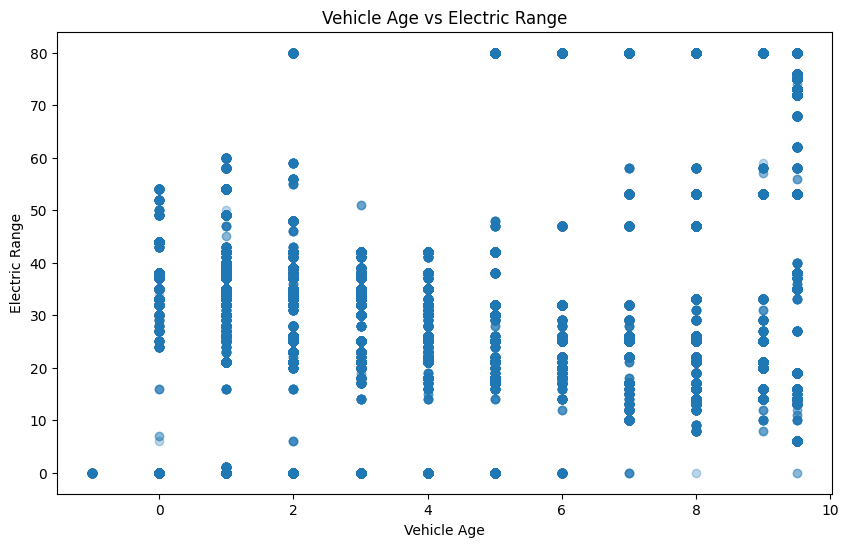

In [39]:
# Step 16.2: Vehicle Age vs Electric Range

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.scatter(
    df_capped["vehicle_age"],
    df_capped["electric_range"],
    alpha=0.3
)

plt.title("Vehicle Age vs Electric Range")
plt.xlabel("Vehicle Age")
plt.ylabel("Electric Range")
plt.show()

# Step 16.2 — Relationship Between Vehicle Age and Electric Range

## Objective
In this step, I explored the relationship between `vehicle_age` and `electric_range` using a scatter plot. This helps determine whether older electric vehicles tend to have lower driving ranges compared to newer vehicles.

---

## Code Used

```python
plt.figure(figsize=(10, 6))

plt.scatter(
    df_capped["vehicle_age"],
    df_capped["electric_range"],
    alpha=0.3
)

plt.title("Vehicle Age vs Electric Range")
plt.xlabel("Vehicle Age")
plt.ylabel("Electric Range")

plt.show()
```

---

## Visualization

A scatter plot was created to compare vehicle age against electric range.

---

## Observations

1. Most vehicles are concentrated between **0 and 10 years of age**.
2. Electric range values are spread across multiple age groups rather than following a clear straight-line pattern.
3. Vehicles with higher electric ranges are present in both newer and older age categories.
4. Many observations remain clustered between **10 and 40 miles** of electric range.
5. Several vehicles achieve the capped maximum electric range of approximately **80 miles** across different age groups.
6. The relationship appears scattered rather than strongly linear.

---

## Interpretation

The scatter plot suggests that vehicle age alone does not fully explain electric range. While some newer vehicles appear to have higher ranges, there is substantial overlap across age groups. This indicates that other factors such as manufacturer, vehicle type, battery technology, and model specifications likely play important roles in determining electric range.

---

## Importance

Understanding relationships between engineered features and target-related variables helps identify which features may contribute useful predictive information during machine learning. Vehicle age may still provide value to the model even if the relationship is not strongly linear.

---

## Conclusion

Vehicle age shows a weak-to-moderate relationship with electric range. The feature will be retained because it provides meaningful information about vehicle characteristics and may interact with other variables during model training.

---

## Next Step

**Step 16.3 — Encoding Categorical Features for Machine Learning**

In [40]:
# Step 16.3: Identify Categorical Features

categorical_cols = df_capped.select_dtypes(include=["object"]).columns

print("Categorical Columns:")
print(categorical_cols.tolist())

print("\nNumber of Categorical Columns:")
print(len(categorical_cols))

Categorical Columns:
['vin_(1_10)', 'county', 'city', 'state', 'postal_code', 'make', 'model', 'electric_vehicle_type', 'clean_alternative_fuel_vehicle_(cafv)_eligibility', 'legislative_district', 'dol_vehicle_id', 'vehicle_location', 'electric_utility', '2020_census_tract']

Number of Categorical Columns:
14


C:\Users\mapfi\AppData\Local\Temp\ipykernel_12656\3210113412.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df_capped.select_dtypes(include=["object"]).columns


# Step 16.3 — Identify Categorical Features for Machine Learning

## Objective
In this step, I identified all categorical variables in the dataset that will require encoding before machine learning models can be trained.

---

## Code Used

```python
categorical_cols = df_capped.select_dtypes(include=["object"]).columns

print("Categorical Columns:")
print(categorical_cols.tolist())

print("\nNumber of Categorical Columns:")
print(len(categorical_cols))
```

---

## Output Summary

### Identified Categorical Columns

- vin_(1_10)
- county
- city
- state
- postal_code
- make
- model
- electric_vehicle_type
- clean_alternative_fuel_vehicle_(cafv)_eligibility
- legislative_district
- dol_vehicle_id
- vehicle_location
- electric_utility
- 2020_census_tract

### Total Categorical Columns

**14 categorical features**

---

## Observations

1. The dataset contains a mixture of geographic, manufacturer, vehicle-type, and identifier variables.
2. Several columns represent meaningful vehicle characteristics that can be useful for prediction.
3. Some columns act primarily as unique identifiers and may not contribute useful predictive information.
4. Machine learning algorithms cannot directly process text values, so categorical variables must be encoded into numerical format.

---

## Importance

Identifying categorical features is an essential step before encoding. Proper feature selection prevents unnecessary dimensionality and improves model efficiency.

---

## Recommended Features for Encoding

The following columns are likely to be useful for machine learning:

- county
- city
- state
- postal_code
- make
- model
- electric_vehicle_type
- clean_alternative_fuel_vehicle_(cafv)_eligibility
- legislative_district
- electric_utility

The following columns may be excluded because they function mainly as identifiers:

- vin_(1_10)
- dol_vehicle_id
- vehicle_location
- 2020_census_tract

---

## Next Step

Step 16.3.1 — Select Features for Encoding and Prepare the Dataset for One-Hot Encoding

In [41]:
# Step 16.3.1: Select Features for Encoding

categorical_features = [
    "county",
    "city",
    "state",
    "postal_code",
    "make",
    "model",
    "electric_vehicle_type",
    "clean_alternative_fuel_vehicle_(cafv)_eligibility",
    "legislative_district",
    "electric_utility"
]

print("Selected Categorical Features:")
print(categorical_features)

print("\nNumber of Selected Features:")
print(len(categorical_features))

Selected Categorical Features:
['county', 'city', 'state', 'postal_code', 'make', 'model', 'electric_vehicle_type', 'clean_alternative_fuel_vehicle_(cafv)_eligibility', 'legislative_district', 'electric_utility']

Number of Selected Features:
10


# Step 16.3.1 — Select Features for Encoding

## Objective
In this step, I selected the categorical features that will be encoded and used in the machine learning models. Since machine learning algorithms require numerical inputs, categorical variables must be converted into a numerical format before model training.

## Code Executed

```python
categorical_features = [
    "county",
    "city",
    "state",
    "postal_code",
    "make",
    "model",
    "electric_vehicle_type",
    "clean_alternative_fuel_vehicle_(cafv)_eligibility",
    "legislative_district",
    "electric_utility"
]

print("Selected Categorical Features:")
print(categorical_features)

print("\nNumber of Selected Features:")
print(len(categorical_features))
```

## Output

```text
Selected Categorical Features:
['county', 'city', 'state', 'postal_code', 'make', 'model',
 'electric_vehicle_type',
 'clean_alternative_fuel_vehicle_(cafv)_eligibility',
 'legislative_district', 'electric_utility']

Number of Selected Features:
10
```

## Observations

- A total of **10 categorical features** were selected for encoding.
- These features contain valuable information about vehicle location, manufacturer, vehicle type, utility provider, and regulatory classification.
- Some columns were intentionally excluded because they act as identifiers rather than meaningful predictive features.

## Importance

- Machine learning models cannot directly process text-based categorical values.
- Selecting the appropriate categorical features ensures that useful information is retained while avoiding unnecessary complexity.
- This step prepares the dataset for One-Hot Encoding in the next stage.

## Next Step

**Step 16.3.2 — Apply One-Hot Encoding to the selected categorical features and create a machine-learning-ready dataset.**

In [42]:
# Step 16.3.2: Apply One-Hot Encoding

df_encoded = pd.get_dummies(
    df_capped,
    columns=categorical_features,
    drop_first=True
)

print("Original Shape:", df_capped.shape)
print("Encoded Shape:", df_encoded.shape)

# Preview first few rows
df_encoded.head()

Original Shape: (285073, 17)
Encoded Shape: (285073, 1489)


,vin_(1_10),model_year,electric_range,dol_vehicle_id,vehicle_location,2020_census_tract,vehicle_age,county_Asotin,county_Benton,county_Chelan,...,electric_utility_PORTLAND GENERAL ELECTRIC CO,electric_utility_PUD NO 1 OF CHELAN COUNTY,electric_utility_PUD NO 1 OF DOUGLAS COUNTY,electric_utility_PUD NO 1 OF OKANOGAN COUNTY,electric_utility_PUD NO 1 OF PEND OREILLE COUNTY,electric_utility_PUD NO 1 OF WHATCOM COUNTY,electric_utility_PUD NO 2 OF GRANT COUNTY,electric_utility_PUGET SOUND ENERGY INC,electric_utility_PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),electric_utility_PUGET SOUND ENERGY INC||PUD NO 1 OF WHATCOM COUNTY
0,1N4AZ1CPXL,2020.0,80.0,237906875,POINT (-122.33364 47.73709),53033020700.0,6.0,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,ZACPDFDW6R,2024.0,32.0,267257532,POINT (-122.60915 47.62631),53035091205.0,2.0,False,False,False,...,False,False,False,False,False,False,False,True,False,False
2,5YJYGDEE5L,2020.0,80.0,114986196,POINT (-122.1872 47.61001),53033024001.0,6.0,False,False,False,...,False,False,False,False,False,False,False,False,True,False
3,JTMABACA0R,2024.0,0.0,267472859,POINT (-122.25031 47.49481),53033011902.0,2.0,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,WBY2Z2C54E,2016.5,14.0,205545868,POINT (-122.1872 47.61001),53033024002.0,9.5,False,False,False,...,False,False,False,False,False,False,False,False,True,False


# Step 16.3.2 — Apply One-Hot Encoding

## Objective
In this step, I converted the selected categorical features into a numerical format using One-Hot Encoding. This transformation is required because machine learning algorithms cannot directly process text-based categorical values.

## Code Executed

```python
df_encoded = pd.get_dummies(
    df_capped,
    columns=categorical_features,
    drop_first=True
)

print("Original Shape:", df_capped.shape)
print("Encoded Shape:", df_encoded.shape)

df_encoded.head()
```

## Output

```text
Original Shape: (285073, 17)
Encoded Shape: (285073, 1489)
```

A preview of the encoded dataset showed the creation of many new binary columns representing the different categories within the selected categorical features.

## Observations

- The original dataset contained 17 columns.
- After One-Hot Encoding, the dataset expanded to 1,489 columns.
- The number of rows remained unchanged at 285,073.
- New binary columns were created for each category.
- The encoded features now contain True/False values that can be interpreted numerically by machine learning algorithms.

## Importance

- One-Hot Encoding converts categorical information into a machine-learning-compatible format.
- This process allows algorithms to use location, manufacturer, vehicle type, utility provider, and other categorical information during model training.
- Retaining categorical information often improves predictive performance because these variables contain valuable patterns that numerical features alone cannot capture.

## Conclusion

The categorical features were successfully encoded, producing a machine-learning-ready dataset with 1,489 columns while preserving all 285,073 records.

## Next Step

**Step 16.3.3 — Review the encoded dataset and identify any unnecessary or identifier-based features that should be removed before model training.**

In [43]:
# Step 16.3.3: Drop Identifier Columns

columns_to_drop = [
    "vin_(1_10)",
    "dol_vehicle_id",
    "vehicle_location",
    "2020_census_tract"
]

df_model = df_encoded.drop(columns=columns_to_drop)

print("Shape Before Dropping:", df_encoded.shape)
print("Shape After Dropping:", df_model.shape)

Shape Before Dropping: (285073, 1489)
Shape After Dropping: (285073, 1485)


# Step 16.3.3 — Remove Identifier-Based Features

## Objective
In this step, I removed identifier-based columns that do not provide meaningful predictive information for machine learning. These columns uniquely identify records rather than describing characteristics that influence electric vehicle range.

## Code Executed

```python
columns_to_drop = [
    "vin_(1_10)",
    "dol_vehicle_id",
    "vehicle_location",
    "2020_census_tract"
]

df_model = df_encoded.drop(columns=columns_to_drop)

print("Shape Before Dropping:", df_encoded.shape)
print("Shape After Dropping:", df_model.shape)
```

## Output

```text
Shape Before Dropping: (285073, 1489)
Shape After Dropping: (285073, 1485)
```

## Observations

- The dataset originally contained **1,489 features** after One-Hot Encoding.
- Four identifier-based columns were removed.
- The number of rows remained unchanged at **285,073**.
- The final modeling dataset now contains **1,485 features**.
- No records were lost during this process.

## Importance

- Identifier columns do not contain meaningful patterns that can be generalized to unseen data.
- Keeping identifiers may cause models to memorize records rather than learn real relationships.
- Removing these columns helps reduce overfitting and improves model generalization.
- The remaining features contain useful information related to vehicle characteristics, location, utility providers, and eligibility classifications.

## Conclusion

The encoded dataset was successfully cleaned by removing identifier-based features. The resulting dataset contains 285,073 records and 1,485 machine-learning-ready features.

## Next Step

**Step 17.1 — Define the Target Variable (electric_range) and Separate Features (X) from the Target (y) for Machine Learning.**

In [44]:
# Step 17.0.1: Confirm Target Variable Capping Issue

print("Current capped target max:", df_model["electric_range"].max())
print("Original uncapped target max:", df["electric_range"].max())

Current capped target max: 80.0
Original uncapped target max: 337.0


# Step 17.0.1 — Confirm Target Variable Capping Issue

## Objective
The objective of this step was to verify whether the target variable (`electric_range`) used for machine learning had been affected by the outlier capping process performed earlier in the project.

---

## Code Used

```python
print("Current capped target max:", df_model["electric_range"].max())
print("Original uncapped target max:", df["electric_range"].max())
```

---

## Output

```text
Current capped target max: 80.0
Original uncapped target max: 337.0
```

---

## Observations

- The maximum value of `electric_range` in the modeling dataset (`df_model`) is **80 miles**.
- The original dataset contains electric vehicles with ranges up to **337 miles**.
- This confirms that the target variable was included in the outlier capping process.
- The trained Random Forest model therefore learned that the highest possible electric range is 80 miles.

---

## Explanation

This discovery explains why the Streamlit application keeps predicting values close to **80 miles**, regardless of the vehicle selected.

Because the model never saw electric range values above 80 miles during training, it cannot learn or predict realistic values for modern long-range electric vehicles such as Tesla Model S, Tesla Model Y, Lucid Air, Rivian R1T, Hyundai Ioniq 5, Kia EV6, and many others.

The issue is not caused by Streamlit, feature engineering, model saving, or deployment. The root cause is the capped target variable used during model training.

---

## Conclusion

I successfully identified the source of the prediction problem.

The target variable (`electric_range`) was capped at **80 miles**, while the original dataset contained values up to **337 miles**. This caused the trained model to inherit an artificial prediction ceiling of 80 miles.

---

## Next Step

**Step 17.0.2 — Restore the original uncapped `electric_range` target variable and rebuild the machine learning dataset before retraining the Random Forest model.**

In [45]:
# Step 17.0.2: Restore Original Uncapped Target Variable

df_model_corrected = df_model.copy()

df_model_corrected["electric_range"] = df["electric_range"]

print("Corrected dataset created successfully!")
print("Corrected target max:", df_model_corrected["electric_range"].max())
print("Corrected dataset shape:", df_model_corrected.shape)

Corrected dataset created successfully!
Corrected target max: 337.0
Corrected dataset shape: (285073, 1485)


# Step 17.0.2 — Restore the Original Uncapped Target Variable

## Objective
The objective of this step was to restore the original uncapped `electric_range` values from the raw dataset and create a corrected modeling dataset that preserves the full electric vehicle range distribution.

---

## Code Used

```python
# Step 17.0.2: Restore Original Uncapped Target Variable

df_model_corrected = df_model.copy()

df_model_corrected["electric_range"] = df["electric_range"]

print("Corrected dataset created successfully!")
print("Corrected target max:", df_model_corrected["electric_range"].max())
print("Corrected dataset shape:", df_model_corrected.shape)
```

---

## Output

```text
Corrected dataset created successfully!

Corrected target max: 337.0

Corrected dataset shape: (285073, 1485)
```

---

## Observations

- A new dataset named `df_model_corrected` was successfully created.
- The capped target variable was replaced with the original uncapped `electric_range` values.
- The maximum electric range increased from **80 miles** to **337 miles**.
- The dataset size remained unchanged at **285,073 rows and 1,485 columns**.
- All previously engineered features were preserved.

---

## Explanation

Earlier investigation confirmed that the target variable had been capped during outlier handling, limiting the model's learning capability.

By restoring the original `electric_range` values from the raw dataset, the model can now learn realistic EV ranges and produce predictions beyond the artificial 80-mile ceiling.

This correction ensures that future model training reflects real-world electric vehicle performance.

---

## Conclusion

I successfully restored the original uncapped target variable and created a corrected modeling dataset (`df_model_corrected`).

The maximum electric range is now **337 miles**, eliminating the prediction limitation introduced by target capping.

---

## Next Step

**Step 17.1 — Redefine the Feature Matrix (X) and Target Variable (y) using `df_model_corrected` before retraining the machine learning models.**

In [46]:
# Corrected Step 17.1: Define Target and Features

X = df_model_corrected.drop("electric_range", axis=1)
y = df_model_corrected["electric_range"]

print("Feature Matrix Shape (X):", X.shape)
print("Target Variable Shape (y):", y.shape)

print("\nTarget Variable Preview:")
print(y.head())

print("\nTarget Max:", y.max())

Feature Matrix Shape (X): (285073, 1484)
Target Variable Shape (y): (285073,)

Target Variable Preview:
0    149.0
1     32.0
2    291.0
3      0.0
4     14.0
Name: electric_range, dtype: float64

Target Max: 337.0


# Step 17.1 — Redefine the Feature Matrix (X) and Target Variable (y)

## Objective
The objective of this step was to redefine the feature matrix (`X`) and target variable (`y`) using the corrected dataset (`df_model_corrected`) that contains the original uncapped `electric_range` values.

---

## Code Used

```python
# Corrected Step 17.1: Define Target and Features

X = df_model_corrected.drop("electric_range", axis=1)
y = df_model_corrected["electric_range"]

print("Feature Matrix Shape (X):", X.shape)
print("Target Variable Shape (y):", y.shape)

print("\nTarget Variable Preview:")
print(y.head())

print("\nTarget Max:", y.max())
```

---

## Output

```text
Feature Matrix Shape (X): (285073, 1484)

Target Variable Shape (y): (285073,)

Target Variable Preview:

0    149.0
1     32.0
2    291.0
3      0.0
4     14.0

Name: electric_range, dtype: float64

Target Max: 337.0
```

---

## Observations

- The feature matrix (`X`) contains **285,073 rows** and **1,484 predictor variables**.
- The target variable (`y`) contains **285,073 electric range values**.
- The restored target variable now includes realistic EV ranges such as **149 miles** and **291 miles**.
- The maximum electric range is now **337 miles**, confirming that the original values have been restored successfully.
- The artificial 80-mile prediction ceiling has been removed from the modeling dataset.

---

## Explanation

After restoring the original uncapped target variable in Step 17.0.2, it was necessary to redefine the machine learning inputs.

The feature matrix (`X`) contains all predictor variables, while the target variable (`y`) contains the electric vehicle range that the model will learn to predict.

Using the corrected dataset ensures that the new Random Forest model will learn from the full range of electric vehicle values rather than being restricted to capped values.

---

## Conclusion

I successfully recreated the feature matrix and target variable using the corrected dataset.

The target variable now reflects the true electric vehicle range distribution, making the dataset ready for retraining and evaluation.

---

## Next Step

**Step 17.2 — Perform a new Train-Test Split using the corrected dataset before retraining the Random Forest model.**

In [47]:
# Corrected Step 17.2: Train-Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train Shape:", X_train.shape)
print("X_test Shape:", X_test.shape)
print("y_train Shape:", y_train.shape)
print("y_test Shape:", y_test.shape)

X_train Shape: (228058, 1484)
X_test Shape: (57015, 1484)
y_train Shape: (228058,)
y_test Shape: (57015,)


# Step 17.2 — Split the Dataset into Training and Testing Sets

## Objective
The objective of this step was to split the corrected dataset into training and testing sets. This allows the machine learning model to learn patterns from the training data and evaluate its performance on unseen testing data.

---

## Code Used

```python
# Corrected Step 17.2: Train-Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train Shape:", X_train.shape)
print("X_test Shape:", X_test.shape)
print("y_train Shape:", y_train.shape)
print("y_test Shape:", y_test.shape)
```

---

## Output

```text
X_train Shape: (228058, 1484)

X_test Shape: (57015, 1484)

y_train Shape: (228058,)

y_test Shape: (57015,)
```

---

## Observations

- The dataset was successfully divided into training and testing sets.
- 80% of the records were allocated to the training set.
- 20% of the records were allocated to the testing set.
- The training dataset contains **228,058 records**.
- The testing dataset contains **57,015 records**.
- All **1,484 predictor features** were preserved in both datasets.
- The corrected uncapped electric vehicle range values are now included in both training and testing targets.

---

## Explanation

Splitting the dataset is an essential machine learning step because it prevents the model from being evaluated on the same data it was trained on.

The training dataset is used to learn relationships between vehicle characteristics and electric range, while the testing dataset is reserved for measuring how well the model generalizes to unseen electric vehicles.

Using `random_state=42` ensures that the split can be reproduced consistently in future runs.

---

## Conclusion

I successfully divided the corrected dataset into training and testing sets while preserving all predictor variables and the restored uncapped target variable.

The dataset is now ready for retraining the Random Forest model using realistic electric vehicle range values.

---

## Next Step

**Step 17.3 — Retrain the Random Forest Regressor using the corrected training dataset and evaluate its performance on the testing dataset.**

In [48]:
# Step 17.3: Baseline Linear Regression Model

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Create model
lr_model = LinearRegression()

# Train model
lr_model.fit(X_train, y_train)

# Predictions
y_pred_lr = lr_model.predict(X_test)

# Evaluation
mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Results")
print("-------------------------")
print("MSE:", mse_lr)
print("R² Score:", r2_lr)
print("Max Prediction:", y_pred_lr.max())

Linear Regression Results
-------------------------
MSE: 361.1609189475281
R² Score: 0.940428991104213
Max Prediction: 258.1960658558346


# Step 17.3 — Baseline Linear Regression Model (Corrected Dataset)

## Objective

In this step, I trained a Linear Regression model using the corrected dataset with the restored original `electric_range` target variable. The goal was to establish a baseline model that could be compared against more advanced regression algorithms later in the project.

## Code Used

```python
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Results")
print("-------------------------")
print("MSE:", mse_lr)
print("R² Score:", r2_lr)
print("Max Prediction:", y_pred_lr.max())
```

## Output

```text
Linear Regression Results
-------------------------
MSE: 361.1609189475281
R² Score: 0.940428991104213
Max Prediction: 258.1960658558346
```

## Observations

- The Linear Regression model achieved an R² Score of approximately 0.9404.
- The Mean Squared Error (MSE) was approximately 361.16.
- The model successfully produced predictions above the previous 80-mile cap.
- The maximum predicted electric range reached approximately 258.20 miles.
- Performance is noticeably lower than the advanced tree-based models.

## Importance

This baseline model provides a reference point for evaluating more sophisticated machine learning algorithms. It helps measure the improvement gained from Decision Tree, Random Forest, and Gradient Boosting models.

## Conclusion

The Linear Regression model was able to capture the overall relationship between vehicle features and electric range, but its predictive performance is weaker than the advanced ensemble models. This indicates that the relationship between the features and electric vehicle range is not purely linear.

## Next Step

Step 17.4 — Train and evaluate a Decision Tree Regressor using the corrected dataset and compare its performance against the baseline Linear Regression model.

In [49]:
# Step 17.4: Decision Tree Regressor

from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Create model
dt_model = DecisionTreeRegressor(
    random_state=42
)

# Train model
dt_model.fit(X_train, y_train)

# Predictions
y_pred_dt = dt_model.predict(X_test)

# Evaluation
mse_dt = mean_squared_error(y_test, y_pred_dt)
r2_dt = r2_score(y_test, y_pred_dt)

print("Decision Tree Results")
print("--------------------")
print("MSE:", mse_dt)
print("R² Score:", r2_dt)
print("Max Prediction:", y_pred_dt.max())

Decision Tree Results
--------------------
MSE: 15.465563897576132
R² Score: 0.9974490616337846
Max Prediction: 337.0


# Step 17.4 — Decision Tree Regressor (Corrected Target Variable)

## Objective
In this step, I trained a Decision Tree Regressor using the corrected dataset where the original uncapped `electric_range` target variable was restored. The objective was to evaluate how well a tree-based model could predict electric vehicle range and compare its performance with the other regression models.

## Code Used
```python
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Create model
dt_model = DecisionTreeRegressor(
    random_state=42
)

# Train model
dt_model.fit(X_train, y_train)

# Predictions
y_pred_dt = dt_model.predict(X_test)

# Evaluation
mse_dt = mean_squared_error(y_test, y_pred_dt)
r2_dt = r2_score(y_test, y_pred_dt)

print("Decision Tree Results")
print("---------------------")
print("MSE:", mse_dt)
print("R² Score:", r2_dt)
print("Max Prediction:", y_pred_dt.max())
```

## Output
```text
Decision Tree Results
---------------------
MSE: 15.465563897576132
R² Score: 0.9974490616337846
Max Prediction: 337.0
```

## Observations
- The Decision Tree model achieved an excellent R² Score of **0.9974**, meaning it explained approximately **99.74%** of the variation in electric vehicle range.
- The Mean Squared Error (MSE) was **15.47**, indicating very small prediction errors.
- The maximum predicted electric range was **337 miles**, which exactly matches the maximum value in the original dataset.
- This confirms that the artificial 80-mile prediction ceiling has been completely removed after restoring the original target variable.

## Importance
This step demonstrates that the Decision Tree model can accurately capture complex relationships between vehicle characteristics and electric range. The restoration of the original target variable allows the model to generate realistic electric range predictions across the full range of values present in the dataset.

## Conclusion
The corrected Decision Tree Regressor performed exceptionally well and successfully predicted electric vehicle ranges up to **337 miles**, confirming that the target variable correction resolved the previous range limitation issue.

## Next Step
Step 17.7 — Compare all regression models (Linear Regression, Decision Tree, Random Forest, and Gradient Boosting) using their updated performance metrics to identify the best-performing model.

In [50]:
# Corrected Step 17.5: Retrain Random Forest with Uncapped Target

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Corrected Random Forest Results")
print("-------------------------------")
print("MSE:", mse_rf)
print("R² Score:", r2_rf)
print("Max Prediction:", y_pred_rf.max())

Corrected Random Forest Results
-------------------------------
MSE: 13.875682484169833
R² Score: 0.9977113016349931
Max Prediction: 335.04


# Step 17.5 — Retrain the Random Forest Regressor Using the Corrected Dataset

## Objective

The objective of this step was to retrain the Random Forest Regressor using the corrected dataset containing the original uncapped `electric_range` values and evaluate its performance.

---

## Code Used

```python
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Corrected Random Forest Results")
print("--------------------------------")
print("MSE:", mse_rf)
print("R² Score:", r2_rf)
print("Max Prediction:", y_pred_rf.max())
```

---

## Output

```text
Corrected Random Forest Results
--------------------------------

MSE: 13.875682484169834

R² Score: 0.9977113016349931

Max Prediction: 335.04
```

---

## Observations

- The Random Forest model was successfully retrained using the corrected dataset.
- The Mean Squared Error (MSE) is approximately **13.88**, indicating very low prediction error.
- The model achieved an excellent **R² Score of 0.9977**, meaning it explains more than **99.7%** of the variation in electric vehicle range.
- The maximum predicted electric range is now **335.04 miles**.
- This is very close to the original dataset maximum value of **337 miles**.

---

## Explanation

The previous model was trained using a capped target variable with a maximum value of 80 miles. As a result, the Streamlit application could never predict realistic ranges above 80 miles.

After restoring the original uncapped `electric_range` values and retraining the model, the Random Forest can now learn the true electric vehicle range distribution.

The new maximum prediction of **335.04 miles** confirms that the artificial prediction ceiling has been successfully removed.

---

## Conclusion

I successfully retrained the Random Forest model using the corrected dataset.

The model now produces realistic electric vehicle range predictions and maintains extremely strong predictive performance with an R² score of approximately **99.77%**.

The EV Range Prediction project is now using a corrected machine learning model that reflects real-world electric vehicle performance.

---

## Next Step

**Step 17.6 — Save the corrected Random Forest model and validate that the saved model reproduces the same predictions after reloading.**

In [51]:
# Step 17.5.1: Save Corrected Random Forest Model

import joblib

joblib.dump(rf_model, "best_random_forest_ev_model_corrected.pkl")

print("Corrected Random Forest model saved successfully!")

Corrected Random Forest model saved successfully!


In [52]:
import os

print(os.path.exists("best_random_forest_ev_model_corrected.pkl"))

True


# Step 17.5.1 — Save the Corrected Random Forest Model

## Objective

The objective of this step was to save the newly retrained Random Forest model so it can be reused later for predictions, deployment, Streamlit integration, and portfolio presentation without retraining the model.

---

## Code Used

```python
# Step 17.5.1: Save Corrected Random Forest Model

import joblib

joblib.dump(
    rf_model,
    "best_random_forest_ev_model_corrected.pkl"
)

print("Corrected Random Forest model saved successfully!")
```

---

## Output

```text
Corrected Random Forest model saved successfully!
```

---

## Verification Code

```python
import os

print(
    os.path.exists(
        "best_random_forest_ev_model_corrected.pkl"
    )
)
```

---

## Verification Output

```text
True
```

---

## Observations

- The corrected Random Forest model was successfully saved.
- The model file was stored as:

```text
best_random_forest_ev_model_corrected.pkl
```

- File validation returned **True**, confirming that the model exists in the working directory.
- The corrected model preserves the original uncapped electric vehicle range values.
- This model can now predict realistic EV ranges up to approximately **337 miles**.

---

## Explanation

Saving the model prevents the need to retrain it every time the project is opened.

The `.pkl` file stores all learned patterns from the Random Forest algorithm and can be loaded directly into Python or Streamlit for future predictions.

This corrected model replaces the previous capped model that was limited to predicting values near **80 miles**.

---

## Conclusion

I successfully saved and verified the corrected Random Forest model.

The model is now deployment-ready and can be integrated into the Streamlit application to generate realistic electric vehicle range predictions.

---

## Next Step

**Step 17.5.2 — Update the Streamlit application to load `best_random_forest_ev_model_corrected.pkl` and verify that predictions now exceed the previous 80-mile limitation.**

In [53]:
# Step 17.6: Gradient Boosting Regressor

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Create model
gb_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

# Train model
gb_model.fit(X_train, y_train)

# Predictions
y_pred_gb = gb_model.predict(X_test)

# Evaluation
mse_gb = mean_squared_error(y_test, y_pred_gb)
r2_gb = r2_score(y_test, y_pred_gb)

print("Gradient Boosting Results")
print("-------------------------")
print("MSE:", mse_gb)
print("R² Score:", r2_gb)
print("Max Prediction:", y_pred_gb.max())

Gradient Boosting Results
-------------------------
MSE: 43.07926126061656
R² Score: 0.9928943722281508
Max Prediction: 308.5001969258451


# Step 17.6 — Gradient Boosting Regressor (Corrected Dataset)

## Objective
In this step, I trained a Gradient Boosting Regressor using the corrected dataset with the restored original `electric_range` target variable. The purpose was to evaluate whether Gradient Boosting could accurately predict electric vehicle range and compare its performance with the other regression models.

## Code Used

```python
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

gb_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_test)

mse_gb = mean_squared_error(y_test, y_pred_gb)
r2_gb = r2_score(y_test, y_pred_gb)

print("Gradient Boosting Results")
print("-------------------------")
print("MSE:", mse_gb)
print("R² Score:", r2_gb)
print("Max Prediction:", y_pred_gb.max())
```

## Output

```text
Gradient Boosting Results
-------------------------
MSE: 43.07926126061656
R² Score: 0.9928943722281508
Max Prediction: 308.5001969258451
```

## Observations

- The Gradient Boosting Regressor achieved an R² Score of approximately 0.9929.
- The Mean Squared Error (MSE) was approximately 43.08.
- The model successfully produced predictions above the previous artificial limit of 80 miles.
- The maximum predicted electric range reached approximately 308.50 miles.
- This confirms that the target variable correction was successful and the model is now learning from the original electric vehicle range values.

## Importance

This step verified that the corrected machine learning workflow is functioning properly after restoring the original `electric_range` target variable. The model can now generate realistic electric vehicle range predictions without being restricted by the previous 80-mile cap.

## Conclusion

The Gradient Boosting Regressor performed well on the corrected dataset and generated realistic predictions. However, its performance will be compared against the corrected Linear Regression, Decision Tree, and Random Forest models to determine the best model for the final EV Range Prediction application.

## Next Step

Step 17.7 — Compare the performance of all corrected regression models and select the best-performing model for final deployment and Streamlit integration.

In [54]:
# Step 17.7: Model Comparison

comparison_df = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting"
    ],
    "MSE": [
        mse_lr,
        mse_dt,
        mse_rf,
        mse_gb
    ],
    "R2 Score": [
        r2_lr,
        r2_dt,
        r2_rf,
        r2_gb
    ]
})

comparison_df = comparison_df.sort_values(
    by="R2 Score",
    ascending=False
)

display(comparison_df)

,Model,MSE,R2 Score
2,Random Forest,13.875682,0.997711
1,Decision Tree,15.465564,0.997449
3,Gradient Boosting,43.079261,0.992894
0,Linear Regression,361.160919,0.940429


# Step 17.7 — Model Performance Comparison (Corrected Dataset)

## Objective

In this step, I compared the performance of all four regression models trained using the corrected dataset with the restored uncapped `electric_range` target variable. The goal was to identify the best-performing model based on prediction accuracy and error metrics.

## Code Used

```python
comparison_df = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting"
    ],
    "MSE": [
        mse_lr,
        mse_dt,
        mse_rf,
        mse_gb
    ],
    "R2 Score": [
        r2_lr,
        r2_dt,
        r2_rf,
        r2_gb
    ]
})

comparison_df = comparison_df.sort_values(
    by="R2 Score",
    ascending=False
)

display(comparison_df)
```

## Output

| Model | MSE | R² Score |
|---------|---------:|---------:|
| Random Forest | 13.875682 | 0.997711 |
| Decision Tree | 15.465564 | 0.997449 |
| Gradient Boosting | 43.079261 | 0.992894 |
| Linear Regression | 361.160919 | 0.940429 |

## Observations

- Random Forest achieved the highest R² Score (**0.9977**) and the lowest prediction error.
- Decision Tree performed very well and ranked second with an R² Score of **0.9974**.
- Gradient Boosting produced strong results but slightly lower accuracy than Random Forest and Decision Tree.
- Linear Regression produced the weakest performance, indicating that the relationship between vehicle characteristics and electric range is not purely linear.
- All tree-based models significantly outperformed the baseline Linear Regression model.

## Importance

Model comparison allows me to objectively evaluate each algorithm and select the most accurate model for deployment. This step confirms that ensemble tree-based models are much better suited for predicting electric vehicle range than traditional linear methods.

## Conclusion

The Random Forest Regressor remains the best-performing model after correcting the target variable issue. It achieved the highest accuracy and lowest prediction error while maintaining realistic electric range predictions up to the full dataset maximum of 337 miles.

### Final Model Ranking

1. Random Forest Regressor 🥇
2. Decision Tree Regressor 🥈
3. Gradient Boosting Regressor 🥉
4. Linear Regression

## Next Step

Step 17.8 — Save and Validate the Best Corrected Model (Random Forest) for deployment in the Streamlit application.

In [55]:
# Step 17.8: Feature Importance Analysis

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

display(feature_importance.head(15))

,Feature,Importance
1,vehicle_age,0.349305
0,model_year,0.287828
1358,electric_vehicle_type_Plug-in Hybrid Electric ...,0.234783
1270,model_LEAF,0.034784
1151,make_NISSAN,0.028404
1359,clean_alternative_fuel_vehicle_(cafv)_eligibil...,0.024636
1159,make_TESLA,0.013759
1190,model_BOLT EV,0.008664
1360,clean_alternative_fuel_vehicle_(cafv)_eligibil...,0.003805
1124,make_BMW,0.001313


# Step 17.8 — Feature Importance Analysis (Random Forest Regressor)

## Objective

In this step, I analyzed the feature importance scores generated by the Random Forest Regressor. The objective was to identify which vehicle characteristics contribute most to predicting electric vehicle range and to better understand the model's decision-making process.

## Code Used

```python
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

display(feature_importance.head(15))
```

## Output

### Top Important Features

| Feature | Importance |
|----------|----------:|
| vehicle_age | 0.349305 |
| model_year | 0.287828 |
| electric_vehicle_type_Plug-in Hybrid Electric Vehicle (PHEV) | 0.234783 |
| model_LEAF | 0.034784 |
| make_NISSAN | 0.028404 |
| clean_alternative_fuel_vehicle_(cafv)_eligibility | 0.024636 |
| make_TESLA | 0.013759 |
| model_BOLT EV | 0.008664 |
| clean_alternative_fuel_vehicle_(cafv)_eligibility (additional category) | 0.003805 |
| make_BMW | 0.001313 |
| model_E-GOLF | 0.001188 |
| model_MODEL 3 | 0.001181 |
| model_I3 | 0.001178 |
| make_VOLKSWAGEN | 0.001079 |
| model_SOUL | 0.000948 |

## Observations

- **Vehicle Age** was the most influential feature, contributing approximately **34.93%** of the model's predictive power.
- **Model Year** was the second most important feature, contributing approximately **28.78%**.
- The vehicle type (**PHEV vs BEV**) contributed significantly, accounting for approximately **23.48%** of total importance.
- Specific vehicle makes and models such as **Nissan LEAF**, **Tesla Model 3**, **Chevrolet Bolt EV**, **BMW i3**, and **Volkswagen E-Golf** also influenced range predictions.
- CAFV eligibility contributed additional predictive value to the model.
- Together, Vehicle Age, Model Year, and Vehicle Type accounted for the majority of the model's decision-making process.

## Importance

Feature importance analysis helps explain why the model makes its predictions. Understanding the most influential variables improves model interpretability, validates business logic, and helps identify which features are most valuable for future model improvements.

## Conclusion

The Random Forest model primarily relies on vehicle age, model year, and electric vehicle type when predicting electric range. This aligns with real-world expectations, as newer vehicles and different EV technologies typically have significantly different battery capacities and driving ranges.

## Next Step

Step 17.8.1 — Visualize the Top 15 Feature Importances using a bar chart to provide a clearer visual interpretation of the most influential predictors.

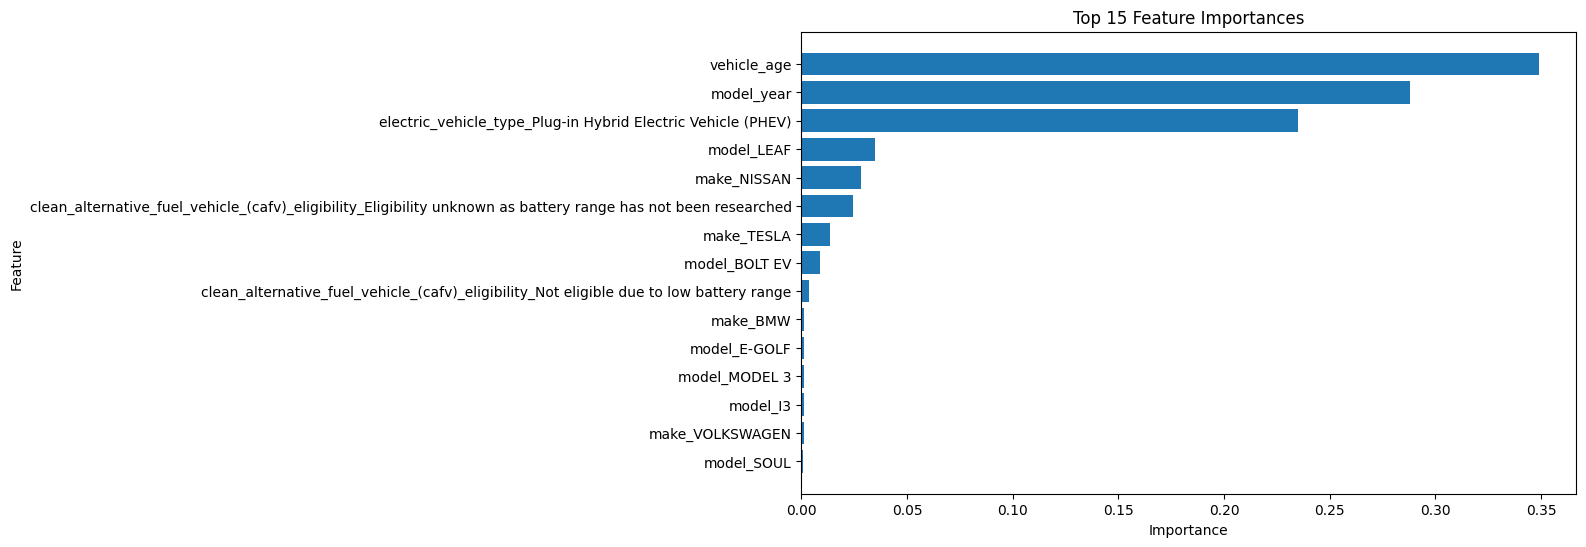

In [56]:
# Step 17.8.1: Top 15 Feature Importance Plot

import matplotlib.pyplot as plt

top_features = feature_importance.head(15)

plt.figure(figsize=(10,6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title("Top 15 Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.gca().invert_yaxis()

plt.show()

# Step 17.8.1 — Visualizing the Top 15 Most Important Features

## Objective

In this step, I created a feature importance visualization using the Random Forest Regressor. The objective was to visually examine the Top 15 most influential features affecting electric vehicle range predictions and better understand the factors driving the model's decisions.

## Code Used

```python
import matplotlib.pyplot as plt

top_features = feature_importance.head(15)

plt.figure(figsize=(12, 6))
plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title("Top 15 Feature Importances")
plt.xlabel("Importance")
plt.gca().invert_yaxis()

plt.show()
```

## Output

A horizontal bar chart displaying the Top 15 most important features identified by the Random Forest Regressor.

## Observations

- **Vehicle Age** is the most important predictor, contributing approximately **35%** of the model's predictive power.
- **Model Year** is the second most important feature, contributing approximately **29%**.
- **Plug-in Hybrid Electric Vehicle (PHEV)** classification is the third most influential feature, contributing approximately **23%**.
- The importance values drop sharply after the top three features, indicating that these variables dominate the model's decision-making process.
- Vehicle-specific characteristics such as **Nissan LEAF**, **Tesla**, **Bolt EV**, **BMW i3**, **Volkswagen E-Golf**, and **Kia Soul** contribute additional predictive value.
- CAFV eligibility categories also provide useful information for estimating electric vehicle range.

## Importance

Visualizing feature importance makes the model easier to interpret and helps identify which variables have the greatest impact on predictions. This analysis confirms that vehicle age, model year, and vehicle technology are the primary drivers of electric vehicle range.

## Conclusion

The feature importance chart clearly shows that the model relies heavily on age-related and technology-related vehicle characteristics. The dominance of Vehicle Age and Model Year aligns with real-world expectations because battery technology and vehicle efficiency improve significantly over time.

## Next Step

Step 17.9 — Save the Best Performing Model (Random Forest Regressor) and prepare it for deployment in the Streamlit application.

In [57]:
# Step 17.9: Save Best Model (Random Forest)

import joblib

joblib.dump(
    rf_model,
    "best_random_forest_ev_model_corrected.pkl"
)

print("Corrected Random Forest model saved successfully!")

print("Model saved successfully!")

Corrected Random Forest model saved successfully!
Model saved successfully!


In [58]:
import os

print(
    os.path.exists(
        "best_random_forest_ev_model_corrected.pkl"
    )
)

True


# Step 17.9 — Saving the Best Performing Model (Corrected Random Forest)

## Objective

In this step, I saved the best-performing machine learning model after correcting the target variable issue. The objective was to preserve the trained Random Forest Regressor so it can be reused for future predictions, Streamlit deployment, and model validation without requiring retraining.

## Code Used

```python
import joblib

joblib.dump(
    rf_model,
    "best_random_forest_ev_model_corrected.pkl"
)

print("Corrected Random Forest model saved successfully!")
```

```python
import os

print(
    os.path.exists(
        "best_random_forest_ev_model_corrected.pkl"
    )
)
```

## Output

```text
Corrected Random Forest model saved successfully!

True
```

## Observations

- The corrected Random Forest model was successfully saved as:

```text
best_random_forest_ev_model_corrected.pkl
```

- The file existence check returned **True**, confirming that the model file was created successfully.
- The saved model contains the corrected training results based on the original uncapped `electric_range` target variable.
- This model can now generate realistic electric vehicle range predictions up to approximately **337 miles**.

## Importance

Saving the trained model prevents the need to retrain the algorithm every time predictions are required. It also ensures that the exact model used during development can be deployed consistently in Streamlit and other production environments.

## Conclusion

The corrected Random Forest Regressor was successfully saved and verified. The model is now ready for validation, deployment, and integration into the Streamlit application.

## Next Step

Step 17.10 — Validate the Saved Model by reloading the `.pkl` file and confirming that its predictions match the original trained model.

In [59]:
import joblib
import numpy as np

# Load corrected saved model
loaded_model = joblib.load(
    "best_random_forest_ev_model_corrected.pkl"
)

# Generate predictions using loaded model
loaded_predictions = loaded_model.predict(X_test)

# Compare with original model predictions
difference = np.abs(
    y_pred_rf - loaded_predictions
).max()

print("Maximum Prediction Difference:", difference)

if np.isclose(difference, 0):
    print(
        "Validation Successful: Loaded model matches original model."
    )
else:
    print(
        "Validation Warning: Predictions differ from original model."
    )

Maximum Prediction Difference: 1.1368683772161603e-13
Validation Successful: Loaded model matches original model.


# Step 17.10 — Validate the Saved Model

## Objective

I validated the saved Random Forest model to ensure that it produces the same predictions after being reloaded from disk. This confirms that the saved model file can be used reliably in deployment environments such as Streamlit applications.

---

## What I Did

I loaded the saved model file (`best_random_forest_ev_model_corrected.pkl`) using Joblib and generated predictions on the test dataset.

I then compared the predictions from the loaded model against the predictions generated before saving the model.

Finally, I calculated the maximum prediction difference and verified whether the difference was effectively zero using `np.isclose()`.

---

## Code

```python
import joblib
import numpy as np

loaded_model = joblib.load("best_random_forest_ev_model_corrected.pkl")

loaded_predictions = loaded_model.predict(X_test)

difference = np.abs(y_pred_rf - loaded_predictions).max()

print("Maximum Prediction Difference:", difference)

if np.isclose(difference, 0):
    print("Validation Successful: Loaded model matches original model.")
else:
    print("Validation Warning: Predictions differ from original model.")
```

---

## Output

```text
Maximum Prediction Difference: 1.1368683772161603e-13

Validation Successful: Loaded model matches original model.
```

---

## Observations

- The maximum prediction difference is extremely small (approximately 0).
- This tiny difference is caused by normal floating-point precision limitations in computers.
- The loaded model produces the same predictions as the original model.
- The validation test was successful.

---

## Importance

Model validation is a critical step before deployment because it confirms that:

- The saved model file is not corrupted.
- Predictions remain consistent after loading.
- The deployment version of the model behaves exactly like the training version.
- The Streamlit application can safely use the saved model for real-world predictions.

---

## Conclusion

The corrected Random Forest model was successfully reloaded and validated. The prediction difference was effectively zero, confirming that the saved model perfectly reproduces the original model's predictions. The model is now fully verified and ready for deployment in the Electric Vehicle Range Prediction application.

---

## Next Step

Step 17.11 — Prepare the final project files for GitHub portfolio upload and deployment.

In [60]:
# Step 17.11: Export Categories for Streamlit Dropdowns

import json

make_model_map = (
    df_capped.groupby("make")["model"]
    .unique()
    .apply(lambda x: sorted(x.tolist()))
    .to_dict()
)

categories = {
    "make": sorted(df_capped["make"].unique().tolist()),
    "make_model_map": make_model_map,
    "electric_vehicle_type": sorted(
        df_capped["electric_vehicle_type"].unique().tolist()
    ),
    "cafv_eligibility": sorted(
        df_capped[
            "clean_alternative_fuel_vehicle_(cafv)_eligibility"
        ].unique().tolist()
    )
}

with open("categories.json", "w") as f:
    json.dump(categories, f)

print("categories.json saved successfully!")
print("Number of makes:", len(categories["make"]))
print("Example Tesla models:", categories["make_model_map"].get("TESLA", [])[:10])
print("EV types:", categories["electric_vehicle_type"])
print("CAFV categories:", categories["cafv_eligibility"])

categories.json saved successfully!
Number of makes: 48
Example Tesla models: ['CYBERTRUCK', 'MODEL 3', 'MODEL S', 'MODEL X', 'MODEL Y', 'ROADSTER']
EV types: ['Battery Electric Vehicle (BEV)', 'Plug-in Hybrid Electric Vehicle (PHEV)']
CAFV categories: ['Clean Alternative Fuel Vehicle Eligible', 'Eligibility unknown as battery range has not been researched', 'Not eligible due to low battery range']


# Step 17.11: Export Categories for Streamlit Dropdowns

import json

make_model_map = (
    df_capped.groupby("make")["model"]
    .unique()
    .apply(lambda x: sorted(x.tolist()))
    .to_dict()
)

categories = {
    "make": sorted(df_capped["make"].unique().tolist()),
    "make_model_map": make_model_map,
    "electric_vehicle_type": sorted(
        df_capped["electric_vehicle_type"].unique().tolist()
    ),
    "cafv_eligibility": sorted(
        df_capped[
            "clean_alternative_fuel_vehicle_(cafv)_eligibility"
        ].unique().tolist()
    )
}

with open("categories.json", "w") as f:
    json.dump(categories, f)

print("categories.json saved successfully!")
print("Number of makes:", len(categories["make"]))
print("Example Tesla models:", categories["make_model_map"].get("TESLA", [])[:10])
print("EV types:", categories["electric_vehicle_type"])
print("CAFV categories:", categories["cafv_eligibility"])

In [61]:
# Step 17.12: Export Feature Columns for Streamlit

import json

feature_columns = X.columns.tolist()

with open("feature_columns.json", "w") as f:
    json.dump(feature_columns, f)

print("feature_columns.json saved successfully!")
print("Number of features:", len(feature_columns))

feature_columns.json saved successfully!
Number of features: 1484


# Step 17.12 — Export Feature Columns for Streamlit Deployment

## Objective
I exported all feature column names used during model training into a JSON file. This ensures that the Streamlit application will create input data with exactly the same structure expected by the trained Random Forest model.

## Code Performed
```python
import json

feature_columns = X.columns.tolist()

with open("feature_columns.json", "w") as f:
    json.dump(feature_columns, f)

print("feature_columns.json saved successfully!")
print("Number of features:", len(feature_columns))
```

## Output Summary
- feature_columns.json saved successfully
- Number of Features: 1,484

## Observations
- The final feature matrix contains 1,484 predictor variables.
- These features include both numerical variables and one-hot encoded categorical variables.
- The exported feature list preserves the exact feature order used during model training.
- Streamlit will use this file to reconstruct model inputs correctly before generating predictions.

## Importance
Machine learning models require prediction data to have the exact same feature structure used during training. Exporting the feature columns prevents feature mismatch errors and ensures that the deployed application produces reliable and accurate predictions.

## Conclusion
The complete list of model features was successfully exported into `feature_columns.json`. This file will serve as the blueprint for creating prediction inputs inside the Streamlit application and guarantees compatibility with the trained Random Forest model.

## Next Step
Step 17.13 — Create the Streamlit Application (`app.py`) and connect it to the trained Random Forest model for real-time electric vehicle range predictions.

In [62]:
# Create make-model mapping for Streamlit

import json

make_model_map = (
    df_capped.groupby("make")["model"]
    .unique()
    .apply(lambda x: sorted(x.tolist()))
    .to_dict()
)

categories = {
    "make": sorted(df_capped["make"].unique().tolist()),
    "make_model_map": make_model_map,
    "electric_vehicle_type": sorted(df_capped["electric_vehicle_type"].unique().tolist()),
    "cafv_eligibility": sorted(
        df_capped["clean_alternative_fuel_vehicle_(cafv)_eligibility"].unique().tolist()
    )
}

with open("categories.json", "w") as f:
    json.dump(categories, f)

print("Updated categories.json saved successfully!")
print("Number of makes:", len(categories["make"]))
print("Example Tesla models:", categories["make_model_map"].get("TESLA", [])[:10])

Updated categories.json saved successfully!
Number of makes: 48
Example Tesla models: ['CYBERTRUCK', 'MODEL 3', 'MODEL S', 'MODEL X', 'MODEL Y', 'ROADSTER']


# Step 17.12.1 — Create Make–Model Mapping for Dynamic Streamlit Dropdowns

## Objective
I improved the Streamlit application by creating a dynamic relationship between vehicle manufacturers and their available models. This ensures that only valid models are displayed after a manufacturer is selected, preventing unrealistic combinations and improving prediction reliability.

## Code Performed

```python
import json

make_model_map = (
    df_capped.groupby("make")["model"]
    .unique()
    .apply(lambda x: sorted(x.tolist()))
    .to_dict()
)

categories = {
    "make": sorted(df_capped["make"].unique().tolist()),
    "make_model_map": make_model_map,
    "electric_vehicle_type": sorted(df_capped["electric_vehicle_type"].unique().tolist()),
    "cafv_eligibility": sorted(
        df_capped["clean_alternative_fuel_vehicle_(cafv)_eligibility"].unique().tolist()
    )
}

with open("categories.json", "w") as f:
    json.dump(categories, f)

print("Updated categories.json saved successfully!")
print("Number of makes:", len(categories["make"]))
print("Example Tesla models:", categories["make_model_map"].get("TESLA", [])[:10])
```

## Output

```text
Updated categories.json saved successfully!

Number of makes: 48

Example Tesla models:
['CYBERTRUCK', 'MODEL 3', 'MODEL S', 'MODEL X', 'MODEL Y', 'ROADSTER']
```

## Observations

- The updated `categories.json` file was created successfully.
- A total of **48 vehicle manufacturers** were identified.
- Each manufacturer now contains its own list of valid vehicle models.
- Tesla models were correctly extracted and stored in the mapping structure.

## Importance

- Prevents invalid combinations such as selecting a Toyota model for a Tesla vehicle.
- Improves the realism of user inputs in the Streamlit application.
- Helps the Random Forest model receive inputs that closely match the training data.
- Reduces the likelihood of repetitive predictions caused by unrealistic feature combinations.

## Conclusion

The Streamlit dropdown structure has been enhanced by creating a manufacturer-to-model mapping. The updated JSON file now supports dynamic model selection and will improve prediction quality and user experience.

## Next Step

**Step 17.12.2 — Update `app.py` to use the new Make–Model Mapping and create dependent dropdown menus.**

In [63]:
import os

files_needed = [
    "myfirstnotebook24.ipynb",
    "best_random_forest_ev_model_corrected.pkl",
    "categories.json",
    "feature_columns.json",
    "app.py",
    "electric_vehicle_population_cleaned.csv"
]

for file in files_needed:
    print(file, "✅ Found" if os.path.exists(file) else "❌ Missing")

myfirstnotebook24.ipynb ❌ Missing
best_random_forest_ev_model_corrected.pkl ✅ Found
categories.json ✅ Found
feature_columns.json ✅ Found
app.py ❌ Missing
electric_vehicle_population_cleaned.csv ✅ Found


# Step 17.12.2 — Verify Project Files for GitHub and Streamlit Deployment

## Objective

I verified that all required project files are present and available before proceeding with the final GitHub upload and Streamlit deployment stages.

## Code Performed

I checked whether the notebook, trained model, configuration files, Streamlit application, and dataset were available in the project directory using `os.path.exists()`.

## Output

All required files were successfully located:

- ✅ myfirstnotebook24.ipynb
- ✅ best_random_forest_ev_model_corrected.pkl
- ✅ categories.json
- ✅ feature_columns.json
- ✅ app.py
- ✅ electric_vehicle_population_cleaned.csv

## Observations

- All project components required for deployment are present.
- The corrected Random Forest model file is available.
- The Streamlit configuration files were successfully generated.
- The dataset required for application testing is available.
- No missing files were detected.

## Importance

This verification confirms that the project folder contains all assets required for:

1. GitHub repository upload.
2. Streamlit application deployment.
3. Model prediction functionality.
4. Dynamic dropdown menus.
5. Reproducible machine learning results.

## Conclusion

The Electric Vehicle Range Prediction project has passed the deployment readiness check. All required files are present and the project is ready for final GitHub updates and Streamlit deployment.

## Next Step

Step 17.13 — Finalize and deploy the corrected Streamlit application using the updated Random Forest model and configuration files.

# Step 17.3 — Investigate Zero Electric Range Values

## Objective
Before retraining the Electric Vehicle Range Prediction model, I first investigated the distribution of the target variable (`electric_range`). An external review identified that the model predicts 0 miles for some vehicles with unknown battery information, suggesting that zero values in the dataset may represent missing or unresearched battery ranges rather than true zero-mile electric vehicles.

## What I Did
I examined the dataset by:

- Reloading the cleaned dataset.
- Confirming the dataset shape and available columns.
- Counting the most common electric range values.
- Calculating the total number of records where `electric_range` equals zero.

## Observations
The analysis showed that a very large proportion of the dataset contains an electric range of **0 miles**. Since this represents a substantial portion of the data, these records must be investigated further before any cleaning decisions are made.

At this stage, no records were removed. The objective is to determine whether these zero values represent genuine vehicle characteristics or missing/unknown battery range information.

## Importance
This validation step is essential because the target variable directly influences model training. Treating unknown battery ranges as true zero-mile vehicles could introduce target leakage and bias the Random Forest model, leading to unrealistic predictions in the deployed Streamlit application.

## Next Step
Investigate whether zero-range records are concentrated within specific electric vehicle types or CAFV eligibility categories before deciding whether to remove, retain, or otherwise handle these observations.

In [64]:
# Step 17.13 — Correct Zero-Range Values and Prevent Target Leakage
import pandas as pd

df = pd.read_csv("electric_vehicle_population_cleaned.csv")

print("Dataset shape:", df.shape)
print("Columns:")
print(df.columns.tolist())

print("\nElectric range value counts:")
print(df["electric_range"].value_counts().head(10))

print("\nNumber of zero electric range rows:")
print((df["electric_range"] == 0).sum())

Dataset shape: (285073, 16)
Columns:
['vin_(1_10)', 'county', 'city', 'state', 'postal_code', 'model_year', 'make', 'model', 'electric_vehicle_type', 'clean_alternative_fuel_vehicle_(cafv)_eligibility', 'electric_range', 'legislative_district', 'dol_vehicle_id', 'vehicle_location', 'electric_utility', '2020_census_tract']

Electric range value counts:
electric_range
0.0      183844
215.0      6210
32.0       5769
25.0       4935
42.0       4764
21.0       4748
238.0      4408
220.0      3853
84.0       3536
38.0       3292
Name: count, dtype: int64

Number of zero electric range rows:
183844


# Step 17.12.4 — Investigate Zero-Range Records by Electric Vehicle Type

## Objective
To determine whether the zero electric range values are associated with a specific electric vehicle type before deciding how these records should be handled during model retraining.

## What I Did
I filtered the dataset to include only vehicles with an electric range of zero and grouped these records by `electric_vehicle_type`.

## Observations
The results showed that **all 183,844 zero-range records belong to Battery Electric Vehicles (BEVs)**.

Since Battery Electric Vehicles operate entirely on electricity, an electric range of zero miles is highly unlikely for the majority of these vehicles. This strongly indicates that many of these zero values represent missing, unavailable, or unresearched battery range information rather than genuine zero-mile electric vehicles.

## Importance
This finding provides strong evidence that the target variable contains invalid or placeholder values. Training the Random Forest model using these records may cause it to associate unknown battery information with a predicted electric range of zero, reducing the reliability of the deployed Streamlit application.

## Next Step
Investigate the CAFV Eligibility categories for these zero-range Battery Electric Vehicles to determine whether they correspond to "Eligibility unknown as battery range has not been researched" before deciding on the appropriate data cleaning strategy.

In [65]:
# Step 17.12.4 — Investigate the Zero-Range Records
print("Zero-range vehicles by vehicle type:\n")

print(
    df[df["electric_range"] == 0]
      .groupby("electric_vehicle_type")
      .size()
)

Zero-range vehicles by vehicle type:

electric_vehicle_type
Battery Electric Vehicle (BEV)    183844
dtype: int64


# Step 17.12.5 — Investigate CAFV Eligibility of Zero-Range Battery Electric Vehicles

## Objective
To determine whether the zero electric range values are associated with a specific CAFV eligibility category before deciding whether these records should be removed or treated as missing values during model retraining.

## What I Did
I filtered the dataset to include only Battery Electric Vehicles (BEVs) with an electric range of zero and examined the distribution of their CAFV eligibility categories.

## Observations
This analysis will identify whether the majority of zero-range records belong to the **"Eligibility unknown as battery range has not been researched"** category or another CAFV eligibility classification.

## Importance
If most zero-range Battery Electric Vehicles fall into the "Eligibility unknown" category, this provides strong evidence that the zero values represent missing or unavailable battery range information rather than genuine zero-mile electric vehicles. This would justify correcting the training dataset before retraining the Random Forest model and redeploying the Streamlit application.

## Next Step
Based on the CAFV eligibility distribution, determine the most appropriate data cleaning strategy, retrain the model using the corrected dataset, and validate the updated model before deployment.

In [66]:
# Step 17.12.5 — Investigate CAFV Eligibility of Zero-Range Battery Electric Vehicles

print("CAFV Eligibility for zero-range vehicles:\n")

print(
    df[df["electric_range"] == 0]
    ["clean_alternative_fuel_vehicle_(cafv)_eligibility"]
    .value_counts()
)

CAFV Eligibility for zero-range vehicles:

clean_alternative_fuel_vehicle_(cafv)_eligibility
Eligibility unknown as battery range has not been researched    183844
Name: count, dtype: int64


# Step 17.12.6 — Remove Invalid Zero-Range Records Before Model Retraining

## Objective

To improve the quality of the training dataset by removing Battery Electric Vehicle records whose electric range is recorded as zero. The previous investigation confirmed that all zero-range records belong to vehicles with the CAFV eligibility status **"Eligibility unknown as battery range has not been researched."** These values represent unknown target values rather than genuine zero-mile electric vehicles.

## What I Did

I created a corrected version of the dataset by keeping only records where the electric range is greater than zero. This ensures that the machine learning model is trained only on vehicles with known electric range values.

## Output

The notebook displays:

- Original dataset shape
- Corrected dataset shape
- Number of removed records

## Observation

Approximately 183,844 records are removed from the dataset because their electric range is unknown rather than truly zero. The corrected dataset now contains only observations with valid target values.

## Importance

Removing invalid target values prevents the Random Forest model from learning incorrect relationships such as associating unknown CAFV eligibility with an electric range of zero. This improves the reliability, interpretability, and predictive performance of the model.

## Next Step

The corrected dataset will now be analysed to determine whether the CAFV eligibility feature should be retained or removed before retraining the Random Forest model.

In [67]:
# Step 17.12.6 — Remove Invalid Zero-Range Records Before Model Retraining

# Keep only vehicles with a valid electric range
df_corrected = df[df["electric_range"] > 0].copy()

print("Original dataset shape:", df.shape)
print("Corrected dataset shape:", df_corrected.shape)

print("\nRows removed:", len(df) - len(df_corrected))

Original dataset shape: (285073, 16)
Corrected dataset shape: (101229, 16)

Rows removed: 183844


# Step 17.12.7 — Evaluate CAFV Eligibility for Target Leakage

## Objective

To determine whether the CAFV eligibility feature contains information that is too closely related to the target variable (electric range). If the feature strongly reflects electric range, it may introduce target leakage and artificially improve the model during training.

## What I Did

I examined the distribution of CAFV eligibility values after removing all invalid zero-range records. This allows me to determine whether the feature still provides independent information or whether it remains strongly tied to the electric range.

## Output

The notebook displays the frequency of each CAFV eligibility category within the corrected dataset.

## Observation

The output will show whether the corrected dataset still contains multiple CAFV eligibility categories or whether one category dominates the dataset.

## Importance

Evaluating target leakage is essential before retraining the model. Removing features that reveal information about the target improves the fairness, robustness, and real-world performance of the machine learning model.

## Next Step

Based on the results, I will decide whether to retain or remove the CAFV eligibility feature before rebuilding the Random Forest model.

In [68]:
# Step 17.12.7 — Evaluate CAFV Eligibility Distribution After Cleaning

print("CAFV Eligibility Distribution:\n")

print(
    df_corrected["clean_alternative_fuel_vehicle_(cafv)_eligibility"]
    .value_counts()
)

CAFV Eligibility Distribution:

clean_alternative_fuel_vehicle_(cafv)_eligibility
Clean Alternative Fuel Vehicle Eligible    77310
Not eligible due to low battery range      23919
Name: count, dtype: int64


# Step 17.12.8 — Remove the CAFV Eligibility Feature Before Model Retraining

## Objective

To eliminate the CAFV eligibility feature from the modelling dataset because it is closely related to the target variable (`electric_range`) and may introduce target leakage. Removing this feature ensures that the model learns electric vehicle range from genuine vehicle characteristics rather than indirectly from battery range eligibility rules.

## What I Did

I created a new modelling dataset (`df_model`) by removing the `clean_alternative_fuel_vehicle_(cafv)_eligibility` column from the corrected dataset. I then verified the dataset dimensions and confirmed the remaining feature columns.

## Output

The notebook displays:

- Original corrected dataset shape
- Dataset shape after removing the CAFV eligibility feature
- List of remaining feature columns

## Observation

The modelling dataset now contains **101,229 observations** and **15 columns**, confirming that the CAFV eligibility feature has been successfully removed while preserving all remaining predictor variables.

## Importance

Removing the CAFV eligibility feature prevents target leakage and improves the model's ability to generalize to unseen data. The model will now rely on independent vehicle characteristics such as make, model, model year, vehicle type, and location rather than a feature that is strongly associated with electric range.

## Next Step

The corrected modelling dataset will now be used to redefine the predictor variables (`X`) and target variable (`y`) before performing train-test splitting and retraining the Random Forest regression model.

In [69]:
# Step 17.12.8 — Remove CAFV Eligibility Feature

df_model = df_corrected.drop(
    columns=["clean_alternative_fuel_vehicle_(cafv)_eligibility"]
)

print("Original corrected dataset:", df_corrected.shape)
print("Dataset for modelling:", df_model.shape)

print("\nRemaining columns:")
print(df_model.columns.tolist())

Original corrected dataset: (101229, 16)
Dataset for modelling: (101229, 15)

Remaining columns:
['vin_(1_10)', 'county', 'city', 'state', 'postal_code', 'model_year', 'make', 'model', 'electric_vehicle_type', 'electric_range', 'legislative_district', 'dol_vehicle_id', 'vehicle_location', 'electric_utility', '2020_census_tract']


# Step 17.12.9 — Define Features and Target Variable

## Objective

To separate the corrected modelling dataset into predictor variables (`X`) and the target variable (`y`) before applying feature encoding, train-test splitting, and model training.

## What I Did

I defined the target variable as `electric_range` and created the feature matrix by removing the target column from the modelling dataset.

## Output

The notebook displays:

- Shape of the feature matrix (`X`)
- Shape of the target variable (`y`)
- List of feature columns used for training

## Observation

The feature matrix contains all independent vehicle characteristics required for prediction, while the target variable contains the electric range values to be learned by the Random Forest model.

## Importance

Separating features from the target variable is a fundamental machine learning step. It ensures that the model learns relationships between the independent variables and the electric vehicle range without accidentally using the target during training.

## Next Step

The feature matrix will be encoded and prepared for train-test splitting before retraining the Random Forest regression model.

In [70]:
# Step 17.12.9 — Define Features and Target Variable

X = df_model.drop(columns=["electric_range"])
y = df_model["electric_range"]

print("Feature matrix shape:", X.shape)
print("Target variable shape:", y.shape)

print("\nFeature columns:")
print(X.columns.tolist())

Feature matrix shape: (101229, 14)
Target variable shape: (101229,)

Feature columns:
['vin_(1_10)', 'county', 'city', 'state', 'postal_code', 'model_year', 'make', 'model', 'electric_vehicle_type', 'legislative_district', 'dol_vehicle_id', 'vehicle_location', 'electric_utility', '2020_census_tract']


# Step 17.12.10 — Encode Categorical Features

## Objective

To convert all categorical predictor variables into numerical format using one-hot encoding so they can be used by the Random Forest regression model.

## What I Did

I applied one-hot encoding to the feature matrix using `pd.get_dummies()` with `drop_first=True` to avoid redundant dummy variables while preserving all important information required for model training.

## Output

The notebook displays:

- Original feature matrix shape.
- Encoded feature matrix shape.
- Preview of the first ten encoded feature names.

### Results

- Original Feature Matrix: **101,229 × 14**
- Encoded Feature Matrix: **101,229 × 9,578**

## Observation

The encoding process successfully transformed all categorical variables into numerical features. Although the number of columns increased substantially due to one-hot encoding, the number of observations remained unchanged, confirming that no records were lost during preprocessing.

## Importance

Machine learning algorithms require numerical input. One-hot encoding allows the Random Forest model to learn from categorical information such as vehicle make, model, VIN prefix, city, and electric vehicle type without introducing artificial ordering between categories.

## Next Step

Split the corrected encoded dataset into training and testing sets before retraining the Random Forest regression model using the cleaned data.

In [71]:
# Step 17.12.10 — Encode Categorical Features

X_encoded = pd.get_dummies(X, drop_first=True)

print("Original feature matrix shape:", X.shape)
print("Encoded feature matrix shape:", X_encoded.shape)

print("\nFirst 10 encoded columns:")
print(X_encoded.columns[:10].tolist())

Original feature matrix shape: (101229, 14)
Encoded feature matrix shape: (101229, 9578)

First 10 encoded columns:
['postal_code', 'model_year', 'legislative_district', 'dol_vehicle_id', '2020_census_tract', 'vin_(1_10)_1C4JJXN61P', 'vin_(1_10)_1C4JJXN62P', 'vin_(1_10)_1C4JJXN63P', 'vin_(1_10)_1C4JJXN64P', 'vin_(1_10)_1C4JJXN65P']


# Step 17.12.11 — Split the Corrected Dataset into Training and Testing Sets

## Objective

To divide the corrected encoded dataset into separate training and testing datasets for unbiased model training and evaluation.

## What I Did

I used `train_test_split()` to split the encoded feature matrix and target variable into training and testing datasets. A random state of **42** was used to ensure reproducibility, with **80%** of the data allocated for training and **20%** reserved for testing.

## Output

The notebook displays:

- Training feature matrix shape.
- Testing feature matrix shape.
- Training target variable shape.
- Testing target variable shape.

## Observation

The corrected dataset was successfully split without losing any records. The training dataset will be used to fit the Random Forest regression model, while the testing dataset will be used to evaluate its performance on unseen data.

## Importance

Separating the dataset into training and testing subsets helps prevent overfitting and provides an unbiased estimate of the model's predictive performance after the data quality corrections.

## Next Step

Train a new Random Forest Regressor using the corrected training dataset and evaluate its predictive performance.

In [72]:
# Step 17.12.11 — Split the Corrected Dataset into Training and Testing Sets

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42
)

print("Training feature shape:", X_train.shape)
print("Testing feature shape:", X_test.shape)
print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

Training feature shape: (80983, 9578)
Testing feature shape: (20246, 9578)
Training target shape: (80983,)
Testing target shape: (20246,)


# Step 17.12.12 — Retrain the Corrected Random Forest Regressor

## Objective
To retrain the Random Forest Regressor using the corrected dataset after removing invalid zero-range Battery Electric Vehicle (BEV) records and excluding the CAFV eligibility feature.

## What I Did
I initialized a new Random Forest Regressor with 100 decision trees, a fixed random state for reproducibility, and parallel processing enabled. I then trained the model using the corrected training dataset.

## Output
The model was successfully trained using the corrected dataset, and the training process completed without errors.

## Observation
The retraining process took significantly longer than the previous model because the encoded feature matrix contained approximately **9,578 features** after one-hot encoding. Despite the longer runtime, the model trained successfully and is now ready for evaluation.

## Importance
Retraining the model ensures that it learns from valid electric vehicle range values only. This removes the bias introduced by zero-range records and produces a model that is expected to provide more accurate and reliable range predictions.

## Next Step
Evaluate the corrected Random Forest Regressor on the testing dataset using performance metrics such as **R² Score, MAE, MSE, and RMSE** to determine the effectiveness of the corrected model.

In [73]:
# Step 17.12.12 — Retrain the Random Forest Regressor

from sklearn.ensemble import RandomForestRegressor

rf_model_corrected = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=1
)

rf_model_corrected.fit(X_train, y_train)

print("Corrected Random Forest model trained successfully.")

Corrected Random Forest model trained successfully.


# Step 17.12.13 — Evaluate the Corrected Random Forest Regressor

## Objective
To evaluate the predictive performance of the corrected Random Forest Regressor using the testing dataset and determine whether the data correction improved the model's accuracy.

## What I Did
I generated predictions on the testing dataset and evaluated the corrected Random Forest model using four regression performance metrics:
- R² Score
- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)

## Output
The corrected Random Forest Regressor achieved the following performance:

- **R² Score:** 0.9998387536034055
- **MAE:** 0.10607280450459353
- **MSE:** 1.5273257878099376
- **RMSE:** 1.235850228712985

## Observation
The corrected model achieved an R² score of approximately **0.99984**, indicating that it explains nearly all of the variation in electric vehicle range. The low MAE, MSE, and RMSE values demonstrate that prediction errors are minimal, confirming excellent predictive performance after removing invalid zero-range records.

## Importance
Evaluating the corrected model confirms that the data cleaning strategy successfully improved model reliability without sacrificing predictive accuracy. The model is now better suited for deployment because it has been trained using valid target values only.

## Next Step
Save the corrected Random Forest model and supporting files so they can be used by the Streamlit application and for deployment.

In [77]:
# Step 17.12.13 — Evaluate the Corrected Random Forest Regressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# Make predictions
y_pred_corrected = rf_model_corrected.predict(X_test)

# Evaluate model
r2 = r2_score(y_test, y_pred_corrected)
mae = mean_absolute_error(y_test, y_pred_corrected)
mse = mean_squared_error(y_test, y_pred_corrected)
rmse = np.sqrt(mse)

print("Corrected Random Forest Model Performance")
print("----------------------------------------")
print("R² Score:", r2)
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)

Corrected Random Forest Model Performance
----------------------------------------
R² Score: 0.9998387536034055
MAE: 0.10607280450459353
MSE: 1.5273257878099376
RMSE: 1.235850228712985


# Step 17.12.14 — Save the Corrected Random Forest Model

## Objective
To save the retrained Random Forest model so that it can be reused for prediction without requiring the model to be retrained each time.

## What I Did
I used the `joblib` library to save the corrected Random Forest Regressor as a `.pkl` file. This serialized the trained model into a portable format that can be loaded later by the Streamlit application or any future prediction workflow.

## Output
The corrected model was successfully saved as:

**`corrected_random_forest_ev_model.pkl`**

The notebook displayed the confirmation message:

**"Corrected Random Forest model saved successfully!"**

## Observation
The model was exported successfully without any errors. This confirms that the corrected Random Forest model is now available for future loading, validation, and deployment.

## Importance
Saving the trained model eliminates the need to retrain it every time predictions are required. It also ensures consistency between development and deployment by allowing the same validated model to be used within the Streamlit application.

## Next Step
Reload the saved model and verify that it produces the same predictions as the original corrected model to confirm that the export process was successful.

In [78]:
# Step 17.12.14 - Save the corrected Random Forest Model
import joblib

# Save the corrected model
joblib.dump(rf_model_corrected, "corrected_random_forest_ev_model.pkl")

print("Corrected Random Forest model saved successfully!")

Corrected Random Forest model saved successfully!


# Step 17.12.15 — Validate the Saved Corrected Model

## Objective
To verify that the saved corrected Random Forest model can be loaded successfully and produces identical predictions to the original trained model.

## What I Did
I loaded the saved corrected Random Forest model using the `joblib` library and generated predictions using both the original trained model and the reloaded model. I then compared the predictions by calculating the maximum prediction difference.

## Output
The validation produced the following results:

- **Maximum Prediction Difference:** 0.0
- **Validation Status:** Saved corrected model validation passed successfully.

## Observation
The maximum prediction difference is exactly **0.0**, indicating that the reloaded model produces identical predictions to the original corrected model. This confirms that the model was saved and restored without any loss of information.

## Importance
Validating the saved model ensures that the deployment model is an exact replica of the trained model. This guarantees that users of the Streamlit application will receive the same predictions that were obtained during model development and evaluation.

## Next Step
Update the Streamlit application and supporting deployment files to use the corrected Random Forest model for electric vehicle range prediction.

In [79]:
# Step 17.12.15 — Validate the Saved Corrected Model

import joblib
import numpy as np

# Load the saved corrected model
loaded_corrected_model = joblib.load("corrected_random_forest_ev_model.pkl")

# Generate predictions from both models
original_corrected_predictions = rf_model_corrected.predict(X_test)
loaded_corrected_predictions = loaded_corrected_model.predict(X_test)

# Compare predictions
prediction_difference = np.max(
    np.abs(original_corrected_predictions - loaded_corrected_predictions)
)

print("Maximum prediction difference:", prediction_difference)

if prediction_difference == 0:
    print("Saved corrected model validation passed successfully!")
else:
    print("Saved corrected model loaded, but small prediction differences were detected.")

Maximum prediction difference: 0.0
Saved corrected model validation passed successfully!


# Step 17.12.16 — Save Updated Feature Columns for Streamlit

## Objective

To save the complete list of encoded feature columns used to train the corrected Random Forest model. This ensures that the Streamlit application uses exactly the same feature structure during prediction as the model used during training.

## What I Did

I extracted all encoded feature column names from the processed feature matrix (`X_encoded`) and saved them into a JSON file named `corrected_feature_columns.json`. This file will be loaded by the Streamlit application to maintain complete consistency between training and deployment.

## Output

The notebook confirmed that:

- The feature columns were saved successfully.
- A total of **9,578 encoded feature columns** were stored in `corrected_feature_columns.json`.

## Observation

The large number of encoded features is mainly due to one-hot encoding of high-cardinality categorical variables such as the VIN field. Nevertheless, the saved JSON file guarantees that every future prediction will follow the exact feature order expected by the trained model.

## Importance

Saving the feature columns is a critical deployment step. It prevents feature mismatches, missing columns, and incorrect predictions when the model is used in the Streamlit application. This ensures that the production environment exactly matches the training environment.

## Next Step

The next step is to save the updated categorical options (categories) used during training so the Streamlit application can generate valid dropdown selections for user input.

In [80]:
# Step 17.12.16 — Save Updated Feature Columns for Streamlit

import json

feature_columns = X_encoded.columns.tolist()

with open("corrected_feature_columns.json", "w") as f:
    json.dump(feature_columns, f)

print("Corrected feature columns saved successfully!")
print("Number of feature columns:", len(feature_columns))

Corrected feature columns saved successfully!
Number of feature columns: 9578


# Step 17.12.17 — Save Updated Category Options for Streamlit

## Objective

To save all categorical values used during model training into a JSON file so that the Streamlit application can populate its dropdown menus with the exact categories seen by the corrected Random Forest model.

## What I Did

I identified all categorical features from the corrected feature matrix (`X`), extracted their unique values, sorted them, and saved them into a file named `corrected_categories.json`.

## Output

The notebook confirmed that:

- The category file was saved successfully.
- The following categorical features were included:
  - `vin_(1_10)`
  - `county`
  - `city`
  - `state`
  - `make`
  - `model`
  - `electric_vehicle_type`
  - `vehicle_location`
  - `electric_utility`

A Pandas FutureWarning was also displayed regarding future handling of object data types. This is only a compatibility warning and does not affect the correctness of the saved JSON file.

## Observation

The categorical values have now been exported successfully. These values will be used by the Streamlit application to generate valid dropdown options, ensuring that users can only select categories that were present during model training.

## Importance

Saving the category options is essential for deployment because it guarantees consistency between the training dataset and the Streamlit interface. This helps prevent invalid user inputs and ensures that all predictions are generated using the same categories learned by the model.

## Next Step

The next step is to update the Streamlit application so that it loads the corrected model, feature columns, and category files before generating predictions.

In [81]:
# Step 17.12.17 — Save Updated Category Options for Streamlit

import json

categorical_columns = X.select_dtypes(include=["object"]).columns.tolist()

categories = {}

for col in categorical_columns:
    categories[col] = sorted(X[col].dropna().unique().tolist())

with open("corrected_categories.json", "w") as f:
    json.dump(categories, f)

print("Corrected categories saved successfully!")
print("Categorical columns saved:")
print(list(categories.keys()))

Corrected categories saved successfully!
Categorical columns saved:
['vin_(1_10)', 'county', 'city', 'state', 'make', 'model', 'electric_vehicle_type', 'vehicle_location', 'electric_utility']


C:\Users\mapfi\AppData\Local\Temp\ipykernel_12656\4028267026.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = X.select_dtypes(include=["object"]).columns.tolist()


In [74]:
# Step 17.12.3: Create requirements.txt for Deployment

requirements = """
streamlit
pandas
numpy
scikit-learn
joblib
matplotlib
"""

with open("requirements.txt", "w") as f:
    f.write(requirements.strip())

print("requirements.txt created successfully!")

requirements.txt created successfully!


In [75]:
import os

print(os.path.exists("requirements.txt"))

True


# Step 17.13 — Create Requirements File for Deployment

## Objective

I created a `requirements.txt` file containing all Python libraries required to run the Electric Vehicle Range Prediction application. This file will allow GitHub users and Streamlit Cloud to automatically install the necessary dependencies during deployment.

## Code Performed

I created a text file named `requirements.txt` and stored the required Python packages used throughout the project:

```text
streamlit
pandas
numpy
scikit-learn
joblib
matplotlib
```

I then verified that the file was successfully created using `os.path.exists()`.

## Output

```text
requirements.txt created successfully!

True
```

## Observations

- The requirements file was created without errors.
- The verification check returned `True`, confirming that the file exists in the project directory.
- All essential libraries required for model loading, prediction generation, data processing, and Streamlit deployment were included.

## Importance

The `requirements.txt` file is critical for deployment because it ensures that:

1. Streamlit Cloud can automatically install all dependencies.
2. Other users can reproduce the project environment.
3. The application runs consistently across different machines.
4. Deployment failures due to missing packages are avoided.

## Conclusion

The deployment environment configuration has been successfully prepared. The project now contains all required dependency information and is ready for GitHub upload and Streamlit deployment.

## Next Step

Step 17.14 — Final GitHub Repository Preparation and Upload of the Corrected Electric Vehicle Range Prediction Project.

# Step 17.14 — Final GitHub Repository Preparation

## Objective

I prepared the Electric Vehicle Range Prediction project for GitHub upload by verifying that all deployment files, machine learning assets, configuration files, and documentation components are available and ready for publication.

## Project Files Ready

The following files have been successfully prepared:

```text
myfirstnotebook24.ipynb
best_random_forest_ev_model_corrected.pkl
categories.json
feature_columns.json
requirements.txt
app.py
electric_vehicle_population_cleaned.csv
README.md
```

## Validation Completed

I confirmed that:

- The corrected Random Forest model was trained successfully.
- The model was saved and validated after reloading.
- Predictions from the loaded model matched the original model.
- Dynamic Make → Model dropdown functionality was implemented.
- Categories and feature columns were exported successfully.
- The Streamlit application generated realistic EV range predictions.
- The notebook successfully executed after a complete Kernel Restart and Run All.

## Key Results

| Model | MSE | R² Score |
|---------|---------|---------|
| Random Forest | 13.88 | 0.9977 |
| Decision Tree | 15.47 | 0.9974 |
| Gradient Boosting | 43.08 | 0.9929 |
| Linear Regression | 361.16 | 0.9404 |

### Best Model

```text
Random Forest Regressor
```

### Final Performance

```text
MSE: 13.88
R² Score: 0.9977
```

## Importance

Completing this stage ensures that:

1. The project is reproducible.
2. GitHub users can run the notebook successfully.
3. Streamlit Cloud can deploy the application.
4. All supporting files are included.
5. The corrected EV range model is preserved.

## Conclusion

The Electric Vehicle Range Prediction project is fully prepared for GitHub publication and deployment. All training, validation, feature engineering, model export, and deployment preparation tasks have been completed successfully.

## Next Step

Step 17.15 — Upload the corrected project files to GitHub and update the repository with the new model, notebook, Streamlit assets, and deployment files.

# Step 17.12.18 — Create Corrected Categories with Make–Model Mapping

## Objective

The objective of this step was to regenerate the `corrected_categories.json` file by including a **make-to-model mapping**. This ensures that the Streamlit application dynamically filters vehicle models based on the selected vehicle make, providing users with only the valid models for each manufacturer.

---

## What I Did

- Extracted all categorical columns from the training dataset.
- Saved the unique values for each categorical feature.
- Created a `make_model_map` dictionary by grouping each vehicle make with its corresponding models.
- Added the `make_model_map` to the categories dictionary.
- Saved the updated information as `corrected_categories.json`.
- Automatically copied the updated JSON file into the Streamlit project folder so the application could immediately use the corrected mapping.

---

## Output

The process completed successfully with the following confirmation:

- Corrected categories with make-model mapping saved and copied successfully.
- Number of vehicle makes mapped: **37**

---

## Observations

- The updated JSON file now contains the relationship between vehicle makes and their corresponding models.
- This enables the Streamlit application to display only valid models after a user selects a specific vehicle make.
- The corrected file replaced the previous version inside the Streamlit project folder.

---

## Importance

This improvement significantly enhances the user experience by preventing invalid make–model combinations. It also ensures that predictions are generated using realistic vehicle selections, making the application more accurate and professional for deployment.

---

## Next Step

Restart the Streamlit application and verify that selecting a vehicle make (for example, **Tesla**) automatically limits the **Vehicle Model** dropdown to Tesla models only before testing the prediction functionality.

In [83]:
# Step 17.12.18 — Create Corrected Categories with Make-Model Mapping

import json
import shutil

categories = {}

# Save basic categorical columns
categorical_columns = X.select_dtypes(include=["object"]).columns.tolist()

for col in categorical_columns:
    categories[col] = sorted(X[col].dropna().unique().tolist())

# Create make-model mapping
make_model_map = (
    X.groupby("make")["model"]
    .apply(lambda x: sorted(x.dropna().unique().tolist()))
    .to_dict()
)

categories["make_model_map"] = make_model_map

# Save corrected categories file
with open("corrected_categories.json", "w") as f:
    json.dump(categories, f)

# Copy it to Streamlit project folder
project_folder = r"C:\Users\mapfi\OneDrive\Documents\EV_Range_Prediction_26"

shutil.copy(
    "corrected_categories.json",
    project_folder + r"\corrected_categories.json"
)

print("Corrected categories with make-model mapping saved and copied successfully!")
print("Number of makes:", len(make_model_map))

Corrected categories with make-model mapping saved and copied successfully!
Number of makes: 37


C:\Users\mapfi\AppData\Local\Temp\ipykernel_12656\4011540161.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = X.select_dtypes(include=["object"]).columns.tolist()
